<table align="left">
  <td>
    <a href="https://colab.research.google.com/github/marco-canas/linear_algebra/blob/main/3_clases_segun_clara_mejia_laverde/1_cap/7_modulo/7_modulo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
  </td>
  <td>
    <a target="_blank" href="https://kaggle.com/kernels/welcome?src=https://github.com/marco-canas/linear_algebra/blob/main/3_clases_segun_clara_mejia_laverde/1_cap/7_modulo/7_modulo.ipynb"><img src="https://kaggle.com/static/images/open-in-kaggle.svg" /></a>
  </td>
</table>

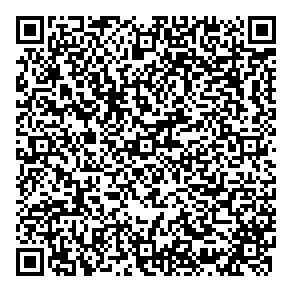

In [1]:
# QR para el cuaderno de clase que permite lectura activa y experimental
import qrcode
from PIL import Image
import os

# URL del notebook en GitHub
url = "https://colab.research.google.com/github/marco-canas/linear_algebra/blob/main/3_clases_segun_clara_mejia_laverde/1_cap/7_modulo/7_modulo.ipynb"

# Configuración del QR
qr = qrcode.QRCode(
    version=1,
    error_correction=qrcode.constants.ERROR_CORRECT_H,
    box_size=4,
    border=4,
)

# Añadir datos al QR
qr.add_data(url)
qr.make(fit=True)

# Crear imagen del QR
img = qr.make_image(fill_color="black", back_color="white")

# Guardar imagen
output_path = "github_notebook_qr.png"
img.save(output_path)

# Mostrar imagen generada (solo si se ejecuta en Jupyter Notebook/Lab)
try:
    display(Image.open(output_path))
except:
    print(f"Código QR generado y guardado en: {os.path.abspath(output_path)}")
    print("Ábralo con cualquier visor de imágenes o escanéelo con su móvil.")
    img.show()  # Abre la imagen en el visor predeterminado



### [Video de apoyo a la lectura del texto guía (Módulo 7)](https://www.youtube.com/watch?v=O6bXHRHbLZU)

### [Video de apoyo a la presentación de teroría y ejemplos en la pizarra digital XP-PEN]()

### [Video de apoyo a la lectura interactiva y experimental del módulo 7 a través del cuaderno Jupyter y Python](https://www.youtube.com/watch?v=v3SqhEkJpts)

### [Vínculo al programa del curso: Linear_Algebra ](https://github.com/marco-canas/linear_algebra/blob/main/3_clases_segun_clara_mejia_laverde/0_programa_cronograma_curso/1_programa_linear_algebra/1_programa_linear_algebra.md)

Código del curso: 5009318  

Un reconocimiento a mis estudiantes que han construido conmigo este saber pedagógico:

<img src = 'https://github.com/marco-canas/linear_algebra/blob/main/images/geo_vectorial_ultima_clase_2025-11-04.jpg?raw=true' width = 300> 



In [1]:
import pandas as pd
import numpy as np

# Cargar la lista de estudiantes desde el archivo CSV
path = 'C:/Users/marco/Documentos/docencia/groups_list/linear_algebra.xlsx'
df = pd.read_excel(path)
df.index = range(1, len(df) + 1)
df.head(11) 


,Cédula,Nombre,Email
1,1007676529,ARENAS HERAZO GABRIEL ENRIQUE,gabriel.arenas@udea.edu.co
2,1038547924,ARROYAVE ECHAVARRIA LAURA SOFIA,sofia.arroyave@udea.edu.co
3,1007528664,AYALA MENDOZA MARISOL YACIRA,marisol.ayala@udea.edu.co
4,1007676170,CANTILLO ENSUCHO DANIEL,daniel.cantillo@udea.edu.co
5,1038104030,IBAÑEZ MORENO FRANCISCO LUIS,francisco.ibanez@udea.edu.co
6,1066570075,MONTERROSA SOTO ABRIL,a.monterrosa@udea.edu.co
7,1038099623,NORIEGA JIMENEZ GABRIELA,gabriela.noriega@udea.edu.co
8,1129805618,PEREZ THERAN ERLINDA,erlinda.perez@udea.edu.co
9,1038101968,QUINONEZ CERVANTES MARIANA,mariana.quinonezc@udea.edu.co
10,1007318378,RAMOS PEREZ YANINE,y.ramos@udea.edu.co


# Módulo 7 Coordenadas y Cambio de base    



### Contenidos del módulo  



1. Vectores coordenados
2. Matrices de transición y cambio de base
3. Vectores coordenados e independencia lineal

# Objetivos del módulo  


1. Introducir bases ordenadas para los espacios vectoriales.


2. Expresar los vectores como vectores de coordenadas.


3. Establecer el manejo algebraico de los vectores de coordenadas.


4. Determinar la matriz de transición de una base a otra en un espacio vectorial.


5. Deducir un algoritmo que permita pasar la expresión de un vector de una base a otra.


6. Utilizar la expresión de un vector como vector coordenado para determinar cuándo un conjunto de vectores es LI.

# Preguntas básicas  introductorias y orientadoras



1. ¿Cómo se expresa un vector como vector coordenado en una base $B$?


2. ¿Cómo se realizan las operaciones de suma y producto por un escalar entre los vectores de coordenadas de un espacio $V$?


3. ¿Cómo están formadas las columnas de la matriz de transición de una base $B_{1}$ a una base $B_{2}$. 


4. ¿Cómo se relacionan las matrices de transición de $B_{1}$ a $B_{2}$ y de $B_{2}$ a $B_{1}$. 

 
5. ¿Cómo se realiza el cambio de la expresión de un vector de una base $B_{1}$ a una base $B_{2}$.


6. ¿Cómo se emplean los vectores coordenados para determinar si un conjunto es LI?

# Introducción


Hemos introducido las llamadas bases estándar o canónicas que, por lo general, son más fáciles de usar. 

Sin embargo, hay muchos problemas de la física y la ingeniería donde es más adecuado el uso de otras bases. 

En este módulo veremos la manera de pasar la expresión de un vector de una base a otra.

# 7.1 Vectores coordenados  



## Definición 1 (Vector Coordenado) 



Sean $V$ un espacio vectorial de dimensión $n$ y $B = \{ \mathbf{v}_{1}, \mathbf{v}_{2}, \ldots, \mathbf{v}_{n} \}$ una base para $V$.
Entonces, para cada $\mathbf{v} \in V$ existen escalares únicos $a_{1}, a_{2}, \ldots, a_{n}$ tales que:

$$
\mathbf{v} = a_{1}\mathbf{v}_{1} + a_{2}\mathbf{v}_{2} + \cdots + a_{n}\mathbf{v}_{n}
$$

El vector cuyos componentes son los escalares $a_{1}, a_{2}, \ldots, a_{n}$ se llama vector de coordenadas o vector coordenado de $v$ con respecto a $B$ y se escribe:  

$$
[\mathbf{v}]_{B} = \begin{bmatrix} a_{1} \\ a_{2} \\ \vdots \\ a_{n} \end{bmatrix}
$$

Es importante observar que $[v]_{B}$ depende del orden de los elementos de $B$. 

Luego al dar la base $B$ debe siempre asumirse ésta como una base ordenada.  



Un vector de coordenadas es una $n$-tupla ordenada.

# Ejemplo 1  
[Video de apoyo para este ejemplo 1 del módulo 7](https://www.youtube.com/watch?v=MgsARWFSys4)


En $\mathbb{R}^{2}$, la base canónica está compuesta por los vectores $\mathbf{e}_{1} = \begin{pmatrix} 1 \\ 0 \end{pmatrix}$ y $\mathbf{e}_{2} = \begin{pmatrix} 0 \\ 1 \end{pmatrix}$, 



pero dos vectores de $\mathbb{R}^{2}$ LI también forman una base para $\mathbb{R}^{2}$, así los vectores $v_{1} = \begin{pmatrix} 1 \\ 2 \end{pmatrix}$ y $v_{2} = \begin{pmatrix} 3 \\ 5 \end{pmatrix}$ forman una base de $\mathbb{R}^{2}$. 



Sea $\mathbf{x} = \begin{pmatrix} -1 \\ -1 \end{pmatrix}$, entonces $x = -1e_{1} - 1e_{2}$.   

Si $B_{1} = \{e_{1}, e_{2} \}$; entonces $(x)_{B_{1}} = \begin{pmatrix} -1\\ -1 \end{pmatrix}$.  



Cuando no se dice explícitamente en qué base está expresado $\mathbf{x}$, se asume que el vector está en la base estándar.  



Sea $B_{2} = \left\{ \begin{pmatrix} 1 \\ 2 \end{pmatrix}, \begin{pmatrix} 3 \\ 5 \end{pmatrix} \right\}$, 

$$
\mathbf{x} = 2\begin{pmatrix} 1 \\ 2 \end{pmatrix} + (-1)\begin{pmatrix} 3 \\ 5 \end{pmatrix}
$$  

luego $(x)_{B_{2}} = \begin{pmatrix} 2 \\ -1 \end{pmatrix}$


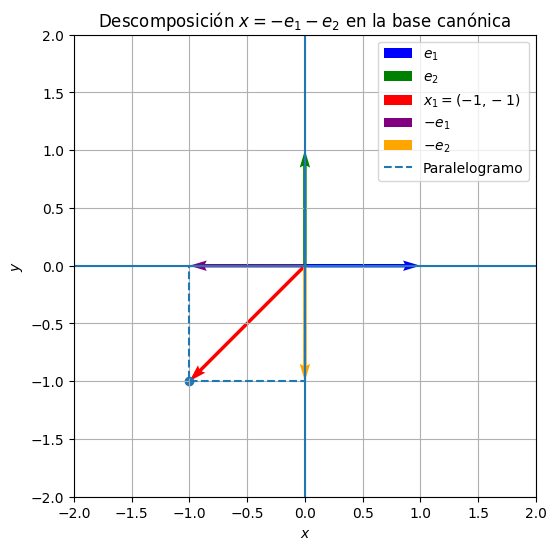

In [1]:
# Representación de x en la base B1 y x en la base B2  

import numpy as np
import matplotlib.pyplot as plt

# =========================
# Vectores
# =========================
x1 = np.array([-1, -1])
e1 = np.array([1, 0])
e2 = np.array([0, 1])

neg_e1 = -e1
neg_e2 = -e2

# =========================
# Figura
# =========================
fig, ax = plt.subplots(figsize=(6,6))

# Ejes coordenados
ax.axhline(0)
ax.axvline(0)

# =========================
# Vectores base canónica (colores distintos)
# =========================
ax.quiver(0, 0, e1[0], e1[1],
          angles='xy', scale_units='xy', scale=1,
          color='blue', label=r'$e_{1}$')

ax.quiver(0, 0, e2[0], e2[1],
          angles='xy', scale_units='xy', scale=1,
          color='green', label=r'$e_{2}$')

# =========================
# Vector x1
# =========================
ax.quiver(0, 0, x1[0], x1[1],
          angles='xy', scale_units='xy', scale=1,
          color='red', label=r'$x_{1}=(-1,-1)$')

# =========================
# Vectores generadores del paralelogramo
# =========================
ax.quiver(0, 0, neg_e1[0], neg_e1[1],
          angles='xy', scale_units='xy', scale=1,
          color='purple', label=r'$-e_{1}$')

ax.quiver(0, 0, neg_e2[0], neg_e2[1],
          angles='xy', scale_units='xy', scale=1,
          color='orange', label=r'$-e_{2}$')

# =========================
# Paralelogramo generado por -e1 y -e2
# =========================
paralelogramo = np.array([
    [0, 0],
    neg_e1,
    neg_e1 + neg_e2,
    neg_e2,
    [0, 0]
])

ax.plot(paralelogramo[:,0], paralelogramo[:,1],
        linestyle='--',
        label='Paralelogramo')

# Punto final del vector x1
ax.scatter(x1[0], x1[1])

# =========================
# Configuración visual
# =========================
ax.set_aspect('equal', adjustable='box')
ax.set_xlim(-2, 2)
ax.set_ylim(-2, 2)
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
ax.set_title('Descomposición $x=-e_1-e_2$ en la base canónica')
ax.grid(True)

# Leyenda
ax.legend()
plt.savefig(r"C:\Users\marco\Downloads\x_en_la_base_b1.png")
plt.show()



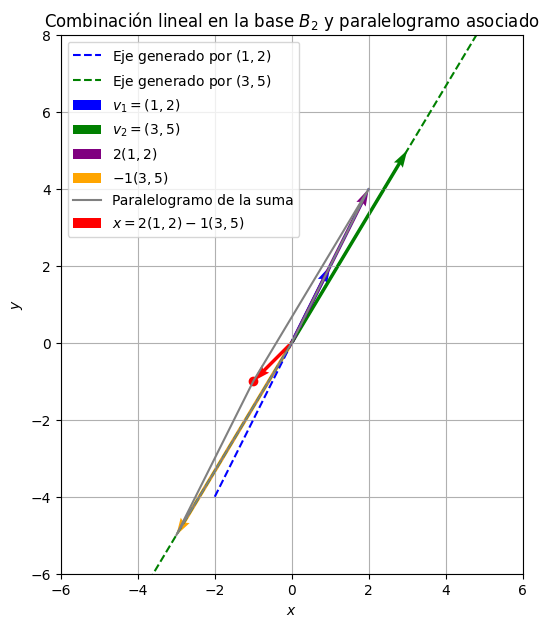

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# Vectores de la base B2
# =========================
v1 = np.array([1, 2])
v2 = np.array([3, 5])

# Combinación lineal
x = 2*v1 - 1*v2

# =========================
# Figura
# =========================
fig, ax = plt.subplots(figsize=(7,7))

# =========================
# "Ejes" generados por los vectores de B2
# (rectas que pasan por el origen en dirección v1 y v2)
# =========================
t = np.linspace(-2, 2, 100)

ax.plot(t*v1[0], t*v1[1], linestyle='--', color='blue',
        label='Eje generado por $(1,2)$')

ax.plot(t*v2[0], t*v2[1], linestyle='--', color='green',
        label='Eje generado por $(3,5)$')

# =========================
# Vectores de la base
# =========================
ax.quiver(0, 0, v1[0], v1[1],
          angles='xy', scale_units='xy', scale=1,
          color='blue', label=r'$v_{1}=(1,2)$')

ax.quiver(0, 0, v2[0], v2[1],
          angles='xy', scale_units='xy', scale=1,
          color='green', label=r'$v_{2}=(3,5)$')

# =========================
# Múltiplos que generan el paralelogramo
# =========================
a = 2*v1
b = -1*v2

ax.quiver(0, 0, a[0], a[1],
          angles='xy', scale_units='xy', scale=1,
          color='purple', label=r'$2(1,2)$')

ax.quiver(0, 0, b[0], b[1],
          angles='xy', scale_units='xy', scale=1,
          color='orange', label=r'$-1(3,5)$')

# =========================
# Paralelogramo de la suma x = 2v1 - v2
# =========================
paralelogramo = np.array([
    [0, 0],
    a,
    a + b,
    b,
    [0, 0]
])

ax.plot(paralelogramo[:,0], paralelogramo[:,1],
        linestyle='-', color='gray',
        label='Paralelogramo de la suma')

# Vector resultado x
ax.quiver(0, 0, x[0], x[1],
          angles='xy', scale_units='xy', scale=1,
          color='red',
          label=r'$x=2(1,2)-1(3,5)$')

ax.scatter(x[0], x[1], color='red')

# =========================
# Configuración visual
# =========================
ax.set_aspect('equal', adjustable='box')
ax.set_xlim(-6, 6)
ax.set_ylim(-6, 8)
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
ax.set_title('Combinación lineal en la base $B_{2}$ y paralelogramo asociado')
ax.grid(True)

# Leyenda
ax.legend()
plt.savefig(r"C:\Users\marco\Downloads\x_en_la_base_b2.png")
plt.show()


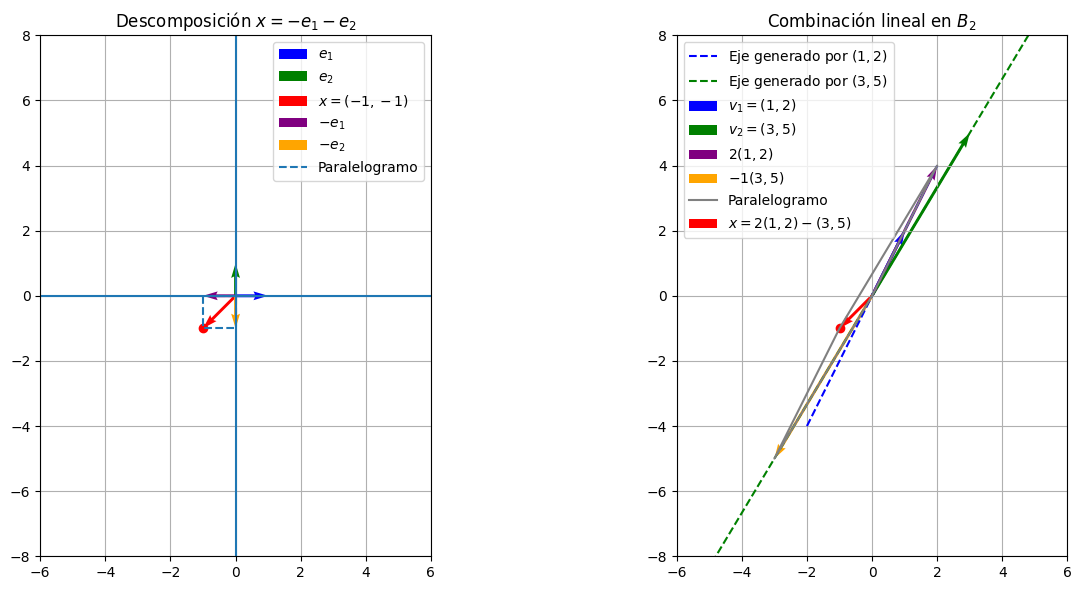

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Rectángulo de visualización común
view = [-6, 6, -8, 8]

# ============================================================
# Crear figura con dos gráficos lado a lado
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14,6))

# ============================================================
# GRÁFICO 1: Base canónica y x = -e1 - e2
# ============================================================
ax = axes[0]

x1 = np.array([-1, -1])
e1 = np.array([1, 0])
e2 = np.array([0, 1])

neg_e1 = -e1
neg_e2 = -e2

# Ejes coordenados
ax.axhline(0)
ax.axvline(0)

# Vectores base canónica
ax.quiver(0, 0, e1[0], e1[1], angles='xy', scale_units='xy', scale=1,
          color='blue', label=r'$e_{1}$')

ax.quiver(0, 0, e2[0], e2[1], angles='xy', scale_units='xy', scale=1,
          color='green', label=r'$e_{2}$')

# Vector x
ax.quiver(0, 0, x1[0], x1[1], angles='xy', scale_units='xy', scale=1,
          color='red', label=r'$x=(-1,-1)$')

# Generadores del paralelogramo
ax.quiver(0, 0, neg_e1[0], neg_e1[1], angles='xy', scale_units='xy', scale=1,
          color='purple', label=r'$-e_{1}$')

ax.quiver(0, 0, neg_e2[0], neg_e2[1], angles='xy', scale_units='xy', scale=1,
          color='orange', label=r'$-e_{2}$')

# Paralelogramo
paralelogramo1 = np.array([
    [0, 0],
    neg_e1,
    neg_e1 + neg_e2,
    neg_e2,
    [0, 0]
])

ax.plot(paralelogramo1[:,0], paralelogramo1[:,1], linestyle='--',
        label='Paralelogramo')

ax.scatter(x1[0], x1[1], color='red')

# MISMO rectángulo de visualización
ax.set_xlim(view[0], view[1])
ax.set_ylim(view[2], view[3])
ax.set_aspect('equal')

ax.set_title('Descomposición $x=-e_1-e_2$')
ax.grid(True)
ax.legend()


# ============================================================
# GRÁFICO 2: Base B2 y x = 2(1,2) - (3,5)
# ============================================================
ax = axes[1]

v1 = np.array([1, 2])
v2 = np.array([3, 5])
x = 2*v1 - v2

# "Ejes" generados por v1 y v2
t = np.linspace(-2, 2, 100)
ax.plot(t*v1[0], t*v1[1], linestyle='--', color='blue',
        label='Eje generado por $(1,2)$')
ax.plot(t*v2[0], t*v2[1], linestyle='--', color='green',
        label='Eje generado por $(3,5)$')

# Vectores base
ax.quiver(0, 0, v1[0], v1[1], angles='xy', scale_units='xy', scale=1,
          color='blue', label=r'$v_{1}=(1,2)$')

ax.quiver(0, 0, v2[0], v2[1], angles='xy', scale_units='xy', scale=1,
          color='green', label=r'$v_{2}=(3,5)$')

# Múltiplos
a = 2*v1
b = -v2

ax.quiver(0, 0, a[0], a[1], angles='xy', scale_units='xy', scale=1,
          color='purple', label=r'$2(1,2)$')

ax.quiver(0, 0, b[0], b[1], angles='xy', scale_units='xy', scale=1,
          color='orange', label=r'$-1(3,5)$')

# Paralelogramo
paralelogramo2 = np.array([
    [0, 0],
    a,
    a + b,
    b,
    [0, 0]
])

ax.plot(paralelogramo2[:,0], paralelogramo2[:,1], color='gray',
        label='Paralelogramo')

# Vector resultado
ax.quiver(0, 0, x[0], x[1], angles='xy', scale_units='xy', scale=1,
          color='red', label=r'$x=2(1,2)-(3,5)$')

ax.scatter(x[0], x[1], color='red')

# MISMO rectángulo de visualización
ax.set_xlim(view[0], view[1])
ax.set_ylim(view[2], view[3])
ax.set_aspect('equal')

ax.set_title('Combinación lineal en $B_{2}$')
ax.grid(True)
ax.legend()

# ============================================================
# Mostrar ambos gráficos
# ============================================================
plt.tight_layout()
plt.savefig(r"C:\Users\marco\Downloads\x_en_las_bases_b1_y_b2.png")
plt.show()


[Video de apoyo para este ejemplo 1 del módulo 7](https://www.youtube.com/watch?v=MgsARWFSys4)

# Ejemplo 2  

En $\mathbb{P}_{2}$, consideremos el polinomio $P(x) = 3 + 2x + x^{2}$, el vector de coordenadas de $P(x)$: 



1. En la base estándar $B = \{1, x, x^{2}\}$, $[P(x)]_{B_{1}} = \begin{pmatrix}3 \\ 2 \\ 1 \end{pmatrix}$.  



2. En la base $B_{2} = \{1+x, 1-x^{2}, 1+x+x^{2} \}$ es? 


Debemos calcular las constantes $c_{1}, c_{2}$ y $c_{3}$ tales que:  

$$
P(x) = c_{1}(1+x) + c_{2}(1-x^{2}) + c_{3}(1+x+x^{2})
$$

lo cual no es más que un problema de combinación lineal. Entonces,  

$$
3 + 2x + x^{2} = (c_{1} + c_{2} + c_{3}) + (c_{1} + c_{3})x + (-c_{2} + c_{3})x^{2}
$$

$$
\begin{align} 
c_{1} + c_{2} + c_{3} & = 3 \\ 
c_{1} + c_{3} & = 2 \\  
-c_{2} + c_{3} & = 1 
\end{align}
$$

El método de **Gauss–Jordan** consiste en transformar el sistema de ecuaciones en una matriz aumentada y aplicar operaciones elementales por filas hasta llevarla a **forma reducida por filas** (identidad a la izquierda). Así se obtiene directamente la solución.

---



Su matriz aumentada es:

$$
\left[
\begin{array}{ccc|c}
1 & 1 & 1 & 3\\ 
1 & 0 & 1 & 2\\ 
0 & -1 & 1 & 1
\end{array}
\right]
$$

---



## 2. Hacer ceros debajo del primer pivote

Usamos la fila 1 como pivote y restamos la fila 1 a la fila 2:

$$
F_2 \leftarrow F_2 - F_1
$$

$$
\left[
\begin{array}{ccc|c}
1 & 1 & 1 & 3\\ 
0 & -1 & 0 & -1\\ 
0 & -1 & 1 & 1
\end{array}
\right]
$$

---



## 3. Convertir el pivote de la fila 2 en 1

Multiplicamos la fila 2 por (-1):

$$
F_2 \leftarrow -F_2
$$

$$
\left[
\begin{array}{ccc|c}
1 & 1 & 1 & 3\\ 
0 & 1 & 0 & 1\\ 
0 & -1 & 1 & 1
\end{array}
\right]
$$

---



## 4. Hacer cero debajo del pivote de la fila 2

Sumamos la fila 2 a la fila 3:

$$
F_3 \leftarrow F_3 + F_2
$$

$$
\left[
\begin{array}{ccc|c}
1 & 1 & 1 & 3\\ 
0 & 1 & 0 & 1\\ 
0 & 0 & 1 & 2
\end{array}
\right]
$$

---



## 5. Hacer ceros arriba de los pivotes (Gauss-Jordan)

Ahora eliminamos hacia arriba.

Primero, eliminamos el 1 en la posición $(1,2)$:

$$
F_1 \leftarrow F_1 - F_2
$$

$$
\left[
\begin{array}{ccc|c}
1 & 0 & 1 & 2\\ 
0 & 1 & 0 & 1\\ 
0 & 0 & 1 & 2
\end{array}
\right]
$$



Luego eliminamos el 1 en la posición $(1,3)$:

$$
F_1 \leftarrow F_1 - F_3
$$



$$
\left[
\begin{array}{ccc|c}
1 & 0 & 0 & 0\\  
0 & 1 & 0 & 1\\  
0 & 0 & 1 & 2
\end{array}
\right]
$$

---



## 6. Interpretar el resultado

Hemos obtenido la matriz identidad a la izquierda, lo que significa que ya está en **forma reducida de Gauss-Jordan**:

$$
\begin{aligned}
c_1 &= 0\\ 
c_2 &= 1\\ 
c_3 &= 2
\end{aligned}
$$

---



## 7. Conclusión didáctica

El proceso Gauss-Jordan sigue esta idea clave:

1. Escribir la matriz aumentada.
2. Crear pivotes (unos) avanzando por columnas.
3. Hacer ceros debajo y encima de cada pivote.
4. Llegar a la identidad.
5. Leer la solución directamente.

Por tanto, la solución del sistema es:

$$
(c_1,c_2,c_3)=(0,1,2).
$$


Así que:  

$$
3 + 2x + x^{2} = 0(1+x) + 1(1-x^{2}) + 2(1 + x + x^{2}) 
$$

Conclusión

$$
[P(x)]_{B_{2}} = \begin{pmatrix} 0\\ 1\\ 2\end{pmatrix}
$$

Recordemos que: 

1. En la base estándar $B = \{1, x, x^{2}\}$, $[P(x)]_{B_{1}} = \begin{pmatrix}3 \\ 2 \\ 1 \end{pmatrix}$.  


# Teorema 1  (Cómo operar con vectores coordenados)

Sea $B$ una base de un espacio vectorial $V$, $\mathbf{u}$ y $\mathbf{v}$ dos vectores de $V$ y $\alpha$ un escalar, entonces:  

1. $[u]_{B} + [v]_{B} = [u+v]_{B}$. 
2. $\alpha [u]_{B} = [\alpha u]_{B}$ 

# Observación  

Con los vectores de coordenadas se opera en la misma forma que en $\mathbb{R}^{n}$.

# 7.2 Matrices de transición y cambio de base. 

Dado un espacio vectorial $V$ con base $B_{1}$, podemos expresar cualquier $\mathbf{v} \in V$ en $B_{1}$. 

 
Si se tiene una segunda base $B_{2}$ para $V$, ¿puede calcularse $(v)_{B_{2}}$ empleando $(v)_{B_{1}}$?

Veamos el problema en $\mathbb{R}^{3}$.  

Sean $B_{1} = \{ v_{1}, v_{2}, v_{3} \}$ y $B_{2} = \{ w_{1}, w_{2}, w_{3} \}$ dos bases para $\mathbb{R}^{3}$. 

Si $v \in \mathbb{R}^{3}$, entonces $(v)_{B_{1}} = \begin{pmatrix}c_{1} \\ c_{2} \\ c_{3} \end{pmatrix}$, es decir  

$$
v = c_{1}v_{1} + c_{2}v_{2} + c_{3}v_{3}.
$$

Ahora, cada uno de los vectores $v_{1}, v_{2}, v_{3}$ podemos expresarlo en la base $B_{2}$, así: 

$$
\begin{align}
v_{1} & = a_{11}w_{1} + a_{12}w_{2} + a_{13}w_{3} \\ 
v_{2} & = a_{21}w_{1} + a_{22}w_{2} + a_{23}w_{3} \\  
v_{3} & = a_{31}w_{1} + a_{32}w_{2} + a_{33}w_{3} 
\end{align}
$$

$$
v = c_{1}(a_{11}w_{1} + a_{12}w_{2} + a_{13}w_{3} ) + \\ 
c_{2}(a_{21}w_{1} + a_{22}w_{2} + a_{23}w_{3}) + \\ 
 c_{3}(a_{31}w_{1} + a_{32}w_{2} + a_{33}w_{3}).
$$

$$
v = (c_{1}a_{11} + c_{2}a_{21} + c_{3}a_{31})w_{1} +\\ 
 (c_{1}a_{12} + c_{2}a_{22} + c_{3}a_{32})w_{2} + \\ 
 (c_{1}a_{13} + c_{2}a_{23} + c_{3}a_{33})w_{3}
$$

Luego   

$$
(v)_{B_{2}} = \begin{pmatrix} c_{1}a_{11} + c_{2}a_{12} + c_{3}a_{13} \\ 
c_{1}a_{21} + c_{2}a_{22} + c_{3}a_{23} \\ 
c_{1}a_{31} + c_{2}a_{32} + c_{3}a_{33}  \end{pmatrix} 
= \begin{pmatrix} a_{11} & a_{12} & a_{13} \\ 
a_{21} & a_{22} & a_{23} \\ 
a_{31} & a_{32} & a_{33}  
\end{pmatrix}\begin{pmatrix} c_{1} \\ c_{2} \\ c_{3} \end{pmatrix}
$$

$$
(v)_{B_{2}} = [(v_{1})_{B_{2}}\ (v_{2})_{B_{2}}\ (v_{3})_{B_{2}}](v)_{B_{1}}
$$

$$
(v)_{B_{2}} = P_{B_{2} \leftarrow B_{1}} (v)_{B_{1}}
$$

# Definición 2  

La matriz $P_{B_{2} \leftarrow B_{1}}$ cuyas columnas son los vectores de la base $B_{1}$ expresadas en la base $B_{2}$ recibe el nombre de matriz de transición de la base $B_{1}$ a la base $B_{2}$.
.

Si $B_{1} = \{v_{1}, v_{2}, \ldots, v_{n}\}$ y $B_{2} = \{w_{1}, w_{2}, \ldots, w_{n}\}$, 

$$
P_{ B_{2}\leftarrow B_{1}} = \begin{bmatrix} a_{11} & a_{12} & \cdots & a_{1n} \\  a_{21} & a_{22} & \cdots & a_{2n} \\ \vdots & \vdots & \cdots & \vdots \\ 
a_{n1} & a_{n2} & \cdots & a_{nn}   \end{bmatrix}
$$

$$
P_{ B_{2}\leftarrow B_{1}} = [(v_{1})_{B_{2}}\ (v_{2})_{B_{2}}\ \cdots \ (v_{n})_{B_{2}} ]
$$

# Teorema 2 

Sean $B_{1}$ y $B_{2}$ bases de un espacio vectorial $V$. Sea $P_{ B_{2}\leftarrow B_{1}}$ la matriz de transición de $B_{1}$ a $B_{2}$; entonces, para todo $\mathbf{x} \in V$,   

$$
(\mathbf{x})_{B_{2}} = P_{ B_{2}\leftarrow B_{1}} (\mathbf{x})_{B_{1}}
$$

# Teorema 3  

Si $P$ es la matriz de transición de $B_{1}$ a $B_{2}$, entonces $P^{-1}$ es la matriz de transición de $B_{2}$ a $B_{1}$.

Este teorema proporciona una forma simple de encontrar la matriz de transición, $P_{B_{2} \leftarrow B_{1}}$, cuando $B_{1}$ es la base estándar de $\mathbb{R}^{n}$. Si  $B_{2} = \{v_{1}, v_{2}, \ldots, v_{n} \}$ es otra base cualquiera, la matriz de transición $P_{B_{1} \leftarrow B_{2}}$ es la matriz cuyas columnas son los vectores de $B_{2}$ expresados en $B_{1}$; como los vectores de $B_{2}$ están dados en la base estándar, entonces  

$$
P_{ B_{1}\leftarrow B_{2}} = [v_{1}\ v_{2}\ \ldots\ v_{n}], 
$$  



o sea que 1 2 B B P← se forma escribiendo la base 2 B como una matriz. Luego, aplicando el teorema, 

$$
P_{ B_{2}\leftarrow B_{1}} = \left( P_{ B_{1}\leftarrow B_{2}} \right)^{-1} 
$$

# Ejemplo 3  

En $\mathbb{R}^{3}$, sean $B_{1} = \left\{ \begin{pmatrix}1\\0\\0 \end{pmatrix}, \begin{pmatrix}0\\1\\0 \end{pmatrix}, \begin{pmatrix}0\\0\\1 \end{pmatrix} \right\}$ y $B_{2} = \left\{ \begin{pmatrix}1\\0\\0 \end{pmatrix}, \begin{pmatrix}1\\1\\0 \end{pmatrix}, \begin{pmatrix}1\\1\\1 \end{pmatrix} \right\}$.  

Expresemos el vector $\begin{pmatrix}x\\y\\z \end{pmatrix} \in \mathbb{R}^{3}$ en términos de la base $B_{2}$.

## Solución:  

Queremos expresar el vector $\begin{pmatrix}x\\ y\\ z\end{pmatrix} \in \mathbb{R}^3$ en la base

$$
B_2 = \left\{
\begin{pmatrix}1 \\ 0 \\ 0\end{pmatrix},
\begin{pmatrix}1 \\ 1 \\ 0\end{pmatrix},
\begin{pmatrix}1 \\ 1 \\ 1\end{pmatrix}
\right\}
$$



usando que la matriz de transición de $B_1$ a $B_2$ es la inversa de la matriz de transición de $B_2$ a $B_1$, y que $B_1$ es la base canónica de $\mathbb{R}^3$.

---



# 1. Idea clave

* $B_1$ es la base canónica: las coordenadas de un vector en $B_1$ son simplemente $(x,y,z)$.
* La matriz de transición de $B_2$ a $B_1$ se forma colocando como columnas los vectores de $B_2$ escritos en coordenadas canónicas.



Es decir:

$$
P_{B_1\to B_2}=
\begin{bmatrix}
1&1&1\\ 
0&1&1\\ 
0&0&1
\end{bmatrix}
$$



Esta matriz transforma coordenadas en base $B_2$ a coordenadas en base canónica.

Por tanto:

$$
[v]_{B_1} = P_{B_1 \leftarrow B_2}[v]_{B_2}
$$



y entonces

$$
[v]_{B_2} = P_{B_2\to B_1}[v]_{B_1}
\quad\text{donde}\quad
P_{B_2\to B_1} = (P_{B_1\to B_2})^{-1}.
$$





# 2. Hallar la inversa de $P_{B_1\leftarrow B_2}$

Calculamos la inversa mediante Gauss-Jordan:

$$
\left[
\begin{array}{ccc|ccc}
1&1&1&1&0&0\\ 
0&1&1&0&1&0\\ 
0&0&1&0&0&1
\end{array}
\right]
$$



Eliminamos hacia arriba:

1. $F_2\leftarrow F_2-F_3$

$$
\left[
\begin{array}{ccc|ccc}
1&1&1&1&0&0\\ 
0&1&0&0&1&-1\\ 
0&0&1&0&0&1
\end{array}
\right]
$$



2. $F_1\leftarrow F_1-F_3$

$$
\left[
\begin{array}{ccc|ccc}
1&1&0&1&0&-1\\ 
0&1&0&0&1&-1\\ 
0&0&1&0&0&1
\end{array}
\right]
$$



3. $F_1\leftarrow F_1-F_2$

$$
\left[
\begin{array}{ccc|ccc}
1&0&0&1&-1&0\\ 
0&1&0&0&1&-1\\ 
0&0&1&0&0&1
\end{array}
\right]
$$



Entonces:

$$
P_{B_2 \leftarrow B_1}=
\begin{bmatrix}
1&-1&0\\ 
0&1&-1\\ 
0&0&1
\end{bmatrix}.
$$

---



# 3. Expresar el vector en la base $B_2$

Sabemos que en la base canónica:

$$
[v]_{B_1}=
\begin{pmatrix}
x\\ y\\ z
\end{pmatrix}.
$$



Entonces:

$$
[v]_{B_2} = P_{B_1 \to B_2}[v]_{B_1}
$$


$$
\begin{bmatrix}
1&-1&0\\  
0&1&-1\\  
0&0&1
\end{bmatrix}
\begin{pmatrix}
x\\  
y\\  
z
\end{pmatrix}.
$$



Multiplicando:

$$
[v]_{B_2}=
\begin{pmatrix}
x-y\\  
y-z\\  
z
\end{pmatrix}.
$$

---



# 4. Interpretación geométrica

Esto significa que el vector $\begin{pmatrix}x\\y\\z\end{pmatrix}$ puede escribirse como combinación lineal de los vectores de la base $B_2$:

$$
\begin{pmatrix}x\\ y\\ z\end{pmatrix}
=
(x-y)\begin{pmatrix}1\\0\\0\end{pmatrix}
+
(y-z)\begin{pmatrix}1\\1\\0\end{pmatrix}
+
z\begin{pmatrix}1\\1\\1\end{pmatrix}.
$$



Los escalares:

$$
(x-y, y-z, z)
$$

son precisamente **las coordenadas del vector en la base $B_2$**.

---



# 5. Conclusión didáctica

El procedimiento general es:

1. Si una base es la canónica, la matriz de transición desde la otra base hacia ella se construye poniendo los vectores de esa base como columnas.
2. La matriz de transición en sentido contrario es su inversa.
3. Multiplicando esta matriz inversa por las coordenadas usuales del vector se obtienen sus coordenadas en la nueva base.



Resultado final:

$$
\boxed{
[v]_{B_2}=
\begin{pmatrix}
x-y\\  
y-z\\  
z
\end{pmatrix}
}
$$

Es decir, esas son las coordenadas del vector $\begin{pmatrix}x\\ y\\ z\end{pmatrix}$ respecto a la base $B_2$.


# Ejemplo 4    

Escribamos el polinomio $a_{0} + a_{1}x + a_{2}x^{2}$ de $\mathbb{P}_{2}$ en términos de la base   

$$
B_{2} = \left\{ 1, x-1, x^{2} - 1 \right\}
$$

Empleando la base estándar, $B_{1} = \{1, x, x^{2}\}$, se tiene:  

$$
(1)_{B_{1}} = \begin{pmatrix} 1\\ 0\\0  \end{pmatrix}, \quad (x-1)_{B_{1}} = \begin{pmatrix} -1\\ 1\\0  \end{pmatrix}, \quad (x^{2}-1)_{B_{1}} = \begin{pmatrix} -1\\ 0\\1  \end{pmatrix}
$$

## Solución:  

Trabajaremos con la misma estrategia usada en $\mathbb{R}^3$: usar matrices de transición entre bases.

Queremos expresar el polinomio
$p(x)=a_{0}+a_{1}x+a_{2}x^{2}\in\mathbb{P}_{2}$ en la base

$$
B_{2}=\{ 1, x-1, x^{2}-1 \}
$$



sabiendo que la base estándar es

$$
B_{1}={1,x,x^{2}}.
$$

---



# 1. Coordenadas de los vectores de $B_{2}$ en la base estándar

Se nos dan:

$$
(1)_{B_{1}} =
\begin{pmatrix}
1\\ 0\\ 0
\end{pmatrix},\qquad
(x-1)_{B_{1}} =
\begin{pmatrix}
-1\\ 1\\ 0
\end{pmatrix},\qquad
(x^{2}-1)_{B_{1}}=
\begin{pmatrix}
-1\\ 0\\ 1
\end{pmatrix}.
$$



Por tanto, la matriz de transición de $B_{2}$ hacia $B_{1}$ se forma colocando estos vectores como columnas:

$$
P_{B_{1}\leftarrow B_{2}} =
\begin{bmatrix}
1&-1&-1\\ 
0&1&0\\ 
0&0&1
\end{bmatrix}.
$$

Esta matriz transforma coordenadas en la base $B_{2}$ a coordenadas en la base estándar.

---



# 2. Relación entre coordenadas

Para cualquier polinomio $p(x)$:

$$
[p]_{B_{1}} = P_{B_{1}\leftarrow B_{2}}[p]_{B_{2}}.
$$



Pero queremos las coordenadas en $B_{2}$, así que:

$$
[p]_{B_{2}} = P_{B_{2}\leftarrow B_{1}}[p]_{B_{1}},
$$



donde

$$
P_{B_{2}\leftarrow B_{1}} =(P_{B_{1}\leftarrow B_{2}})^{-1}.
$$

---

# 3. Invertir la matriz (Gauss–Jordan)



Partimos de

$$
\left[
\begin{array}{ccc|ccc}
1&-1&-1&1&0&0\\  
0&1&0&0&1&0\\  
0&0&1&0&0&1
\end{array}
\right].
$$



Eliminamos hacia arriba usando los pivotes:

1. $F_{1}\leftarrow F_{1}+F_{2}$

$$
\left[
\begin{array}{ccc|ccc}
1&0&-1&1&1&0\\  
0&1&0&0&1&0\\  
0&0&1&0&0&1
\end{array}
\right]
$$



2. $F_{1}\leftarrow F_{1}+F_{3}$

$$
\left[
\begin{array}{ccc|ccc}
1&0&0&1&1&1\\  
0&1&0&0&1&0\\  
0&0&1&0&0&1
\end{array}
\right].
$$



Por tanto,

$$
P_{B_{2}\leftarrow B_{1}} =
\begin{bmatrix}
1&1&1\\  
0&1&0\\  
0&0&1
\end{bmatrix}.
$$

---



# 4. Coordenadas del polinomio en la base estándar

El polinomio

$$
p(x)=a_{0}+a_{1}x+a_{2}x^{2}
$$



tiene coordenadas en $B_{1}$:

$$
[p]_{B_{1}}=
\begin{pmatrix}
a_{0}\\  
a_{1}\\  
a_{2}
\end{pmatrix}.
$$

---



# 5. Coordenadas del polinomio en la base $B_{2}$

Aplicamos la matriz de transición:

$$
[p]_{B_{2}}=
P_{B_{1}\to B_{2}}
\begin{pmatrix}
a_{0}\\  
a_{1}\\  
a_{2}
\end{pmatrix}
=
\begin{bmatrix}
1&1&1\\  
0&1&0\\  
0&0&1
\end{bmatrix}
\begin{pmatrix}
a_{0}\\ 
a_{1}\\  
a_{2}
\end{pmatrix}.
$$



Multiplicando:

$$
[p]_{B_{2}}=
\begin{pmatrix}
a_{0}+a_{1}+a_{2}\\ 
a_{1}\\ 
a_{2}
\end{pmatrix}.
$$

---



# 6. Expresión del polinomio en la base $B_{2}$

Esto significa que

$$
p(x)=
(a_{0}+a_{1}+a_{2})\cdot 1
+
a_{1}(x-1)
+
a_{2}(x^{2}-1).
$$



Es decir, los coeficientes respecto a la base $B_{2}$ son:

$$
(p)_{B_{2}}=
\left(a_{0}+a_{1}+a_{2}, a_{1}, a_{2}\right).
$$

---



# 7. Interpretación didáctica

El procedimiento general es el mismo que en espacios vectoriales como $\mathbb{R}^{3}$:

1. Expresar los vectores de la nueva base en la base estándar.
2. Formar la matriz de transición $P_{B_{1} \leftarrow B_{2}}$.
3. Invertirla para obtener $P_{B_{2}\leftarrow B_{1}}$.
4. Multiplicar esta matriz por las coordenadas estándar del objeto (vector o polinomio).

Resultado final:

$$
\boxed{
(p)_{B_{2}}=
\begin{pmatrix}
a_{0}+a_{1}+a_{2}\\ 
a_{1}\\ 
a_{2}
\end{pmatrix}
}
$$



Estas son las coordenadas del polinomio $a_{0}+a_{1}x+a_{2}x^{2}$ en la base $B_{2} = \{1,x-1, x^{2}-1 \}$.


# Ejemplo 5

En $R^{2}$, supongamos que $(x)_{B_{1}} = \begin{pmatrix} 2 \\ -1 \end{pmatrix}$, donde 

$$
B_{1} \left\{\begin{pmatrix} 1 \\ 1 \end{pmatrix}, \begin{pmatrix} 2 \\ 3 \end{pmatrix}  \right\}, 
$$

expresemos $x$ en la base 

$$
B_{2} \left\{\begin{pmatrix} 0 \\ 3 \end{pmatrix}, \begin{pmatrix} 5 \\ -1 \end{pmatrix}  \right\}, 
$$



# Resumen operativo   
Podemos observar que para obtener la matriz de transición de $B_{1}$ a $B_{2}$,hacemos lo siguiente:
$$
[B_{2} | B_{1}] \to \text{operaciones elementales de fila}  \to [I| P_{B_{2} \leftarrow B_{1}}]
$$

# 7.3 Vectores coordenados e independencia lineal  



# Ejemplo 6 

# Problema editado

En el espacio vectorial de los polinomios de grado menor o igual que tres

$$
\mathbb{P}_3
$$

determine si el conjunto de polinomios

$$
\{ 1+x^2, -1-3x+4x^2+5x^3, 2+5x-6x^3, 4+6x+3x^2+7x^3 \}
$$

es **linealmente dependiente (LD)** o **linealmente independiente (LI)**.



Utilice la base estándar de $\mathbb{P}_3$

$$
B=\{1,x,x^2,x^3\}
$$

y determine si existe una combinación lineal no trivial de estos polinomios que produzca el polinomio cero.

---



# Paso 1: Expresar los polinomios en la base estándar

En la base

$$
B=\{1,x,x^2,x^3\}
$$

los vectores de coeficientes son:



### Primer polinomio

$$
p_1=1+x^2
$$

vector

$$
(1,0,1,0)
$$

---



### Segundo polinomio

$$
p_2=-1-3x+4x^2+5x^3
$$

vector

$$
(-1,-3,4,5)
$$

---



### Tercer polinomio

$$
p_3=2+5x-6x^3
$$

vector

$$
(2,5,0,-6)
$$

---



### Cuarto polinomio

$$
p_4=4+6x+3x^2+7x^3
$$

vector

$$
(4,6,3,7)
$$

---



# Paso 2: Construir la matriz

Colocamos los vectores como columnas:

$$
A=
\begin{bmatrix}
1 & -1 & 2 & 4 \\ 
0 & -3 & 5 & 6 \\ 
1 & 4 & 0 & 3 \\ 
0 & 5 & -6 & 7
\end{bmatrix}
$$

El conjunto será **LI si**

$$
\det(A)\neq 0
$$

---



# Paso 3: Eliminación gaussiana

Restamos fila 1 a fila 3:

$$
F_3 \leftarrow F_3-F_1
$$

$$
\begin{bmatrix}
1 & -1 & 2 & 4 \\ 
0 & -3 & 5 & 6 \\ 
0 & 5 & -2 & -1 \\ 
0 & 5 & -6 & 7
\end{bmatrix}
$$

---



Multiplicamos $F_2$ por $-\frac13$

$$
F_2=(0,1,-5/3,-2)
$$

Eliminamos debajo:

$$
F_3 \leftarrow F_3-5F_2
$$

$$
F_4 \leftarrow F_4-5F_2
$$



Obtenemos

$$
\begin{bmatrix}
1 & -1 & 2 & 4 \\ 
0 & 1 & -5/3 & -2 \\ 
0 & 0 & 19/3 & 9 \\ 
0 & 0 & 7/3 & 17
\end{bmatrix}
$$

---



Eliminamos en la cuarta fila:

$$
F_4 \leftarrow F_4-\frac{7}{19}F_3
$$

El pivote final es

$$
\frac{260}{19}\neq 0
$$

---



# Paso 4: Determinante

El determinante es distinto de cero.

Por lo tanto:

$$
\det(A)\neq0
$$

---



# Conclusión

Los vectores de coeficientes son linealmente independientes.

Por lo tanto:

$$
\{ 1+x^2, -1-3x+4x^2+5x^3, 2+5x-6x^3, 4+6x+3x^2+7x^3 \}
$$

es un conjunto **linealmente independiente en $\mathbb{P}_3$**.

---



# Interpretación didáctica (muy útil para tus estudiantes)

El espacio

$$
\mathbb{P}_3
$$

tiene dimensión

$$
4
$$

y tenemos **4 polinomios**.

Como son **LI**, entonces forman una **base de $\mathbb{P}_3$**.

---



# Ejercicios — Módulo 7

## Coordenadas respecto a una base

En los ejercicios siguientes, **todas las bases están ordenadas**.

En los ejercicios **1 a 7**, calcule el **vector coordenado de $v$ respecto a la base $B$** del espacio vectorial $V$.

---



# Ejercicio 1

$$
V=\mathbb{R}^2
$$

$$
B=\left\{
\begin{pmatrix}1\\ 0\end{pmatrix},
\begin{pmatrix}0\\ 1\end{pmatrix}
\right\}
$$

$$
v=
\begin{pmatrix}
3\\ 1
\end{pmatrix}
$$

---



## Solución

Esta es la **base estándar**, por lo tanto

$$
[v]_B=
\begin{pmatrix}
3\\ 1
\end{pmatrix}
$$

---



### Python



In [1]:
import sympy as sp

B = sp.Matrix([[1,0],[0,1]])
v = sp.Matrix([3,1])

coords = B.LUsolve(v)

coords


Matrix([
[3],
[1]])


# Ejercicio 2

$$
V=\mathbb{R}^3
$$

Base estándar

$$
B=
\left\{
\begin{pmatrix}1\\ 0\\ 0\end{pmatrix},
\begin{pmatrix}0\\ 1\\ 0\end{pmatrix},
\begin{pmatrix}0\\ 0\\ 1\end{pmatrix}
\right\}
$$

$$
v=
\begin{pmatrix}
4\\ -1\\ 0
\end{pmatrix}
$$

---



## Solución

Al ser la base estándar

$$
[v]_B=
\begin{pmatrix}
4\\ -1\\ 0
\end{pmatrix}
$$

---



### Python


In [2]:
B = sp.eye(3)
v = sp.Matrix([4,-1,0])

coords = B.LUsolve(v)
coords


Matrix([
[ 4],
[-1],
[ 0]])


# Ejercicio 3

$$
V=\mathbb{R}^3
$$

Base

$$
B=
\left\{
\begin{pmatrix}1\\ -1\\ 0\end{pmatrix},
\begin{pmatrix}0\\ 1\\ 0\end{pmatrix},
\begin{pmatrix}1\\ 0\\ 2\end{pmatrix}
\right\}
$$

Vector

$$
v=
\begin{pmatrix}
2\\ 3\\ -1
\end{pmatrix}
$$

---



## Solución con Python


In [3]:
B = sp.Matrix([
[1,0,1],
[-1,1,0],
[0,0,2]
])

v = sp.Matrix([2,3,-1])

coords = B.LUsolve(v)

coords


Matrix([
[ 5/2],
[11/2],
[-1/2]])


Resultado:

$$
[v]_B=
\begin{pmatrix}
5\\ 8\\ -1/2
\end{pmatrix}
$$

---



# Ejercicio 4

$$
V=\mathbb{P}_1
$$

Base

$$
B=\{ 1+x, -1+2x \}
$$

Vector

$$
v=3+4x
$$

---



## Planteamiento

Buscamos

$$
c_1(1+x)+c_2(-1+2x)=3+4x
$$

---



## Sistema

Constante:

$$
c_1-c_2=3
$$

Coeficiente de $x$

$$
c_1+2c_2=4
$$

---



## Solución

$$
c_2=\frac13
$$

$$
c_1=\frac{10}{3}
$$

---



### Coordenadas

$$
[v]_B=
\begin{pmatrix}
10/3\\ 
1/3
\end{pmatrix}
$$

---



### Python


In [4]:
c1,c2=sp.symbols('c1 c2')

eq1=sp.Eq(c1-c2,3)
eq2=sp.Eq(c1+2*c2,4)

sp.solve([eq1,eq2],[c1,c2])


{c1: 10/3, c2: 1/3}


# Ejercicio 5

$$
V=\mathbb{P}_2
$$

Base

$$
B=\{1,x-1,x^2-1\}
$$

Vector

$$
v=1+2x-x^2
$$

---



## Planteamiento

Buscamos

$$
c_1(1)+c_2(x-1)+c_3(x^2-1)=1+2x-x^2
$$

Expandiendo:

Constante

$$
c_1-c_2-c_3
$$

$x$

$$
c_2
$$

$x^2$

$$
c_3
$$

---



## Sistema

$$
c_3=-1
$$

$$
c_2=2
$$

$$
c_1-c_2-c_3=1
$$

---



## Solución

$$
c_1=2
$$

---



### Coordenadas

$$
[v]_B=
\begin{pmatrix}
2\\ 2\\ -1
\end{pmatrix}
$$

---

### Python



In [5]:
c1,c2,c3=sp.symbols('c1 c2 c3')

eq1=sp.Eq(c1-c2-c3,1)
eq2=sp.Eq(c2,2)
eq3=sp.Eq(c3,-1)

sp.solve([eq1,eq2,eq3],[c1,c2,c3])


{c1: 2, c2: 2, c3: -1}


# Ejercicio 6

$$
V=\mathbb{P}_2
$$

Base

$$
B=\{1-x+x^2, 1+x, 1+x^2 \}
$$

Vector

$$
v=3-2x+4x^2
$$

---



### Python



In [6]:
c1,c2,c3=sp.symbols('c1 c2 c3')

eq1=sp.Eq(c1 + c2 + c3,3)
eq2=sp.Eq(-c1 + c2,-2)
eq3=sp.Eq(c1 + c3,4)

sp.solve([eq1,eq2,eq3],[c1,c2,c3])


{c1: 1, c2: -1, c3: 3}


# Ejercicio 7

Espacio

$$
V=M_{2\times2}
$$

Vector

$$
V=
\begin{pmatrix}
2&0\\ 
-1&3
\end{pmatrix}
$$

Se expresan todas las matrices como vectores en $\mathbb{R}^4$.

---



### Python



In [7]:
B = sp.Matrix([
[1,1,1,1],
[0,0,1,1],
[0,1,0,1],
[0,0,0,1]
])

v = sp.Matrix([2,0,-1,3])

coords = B.LUsolve(v)

coords


Matrix([
[ 6],
[-4],
[-3],
[ 3]])


# Ejercicios 8–10

## Matrices de transición

Se dan las bases

$$
B_1=
\left\{
\begin{pmatrix}1\\ 3\end{pmatrix},
\begin{pmatrix}-2\\ 1\end{pmatrix}
\right\}
$$

$$
B_2=
\left\{
\begin{pmatrix}\frac{1}{\sqrt2}\\ -\frac{1}{\sqrt2}\end{pmatrix},
\begin{pmatrix}\frac{1}{\sqrt2}\\ \frac{1}{\sqrt2}\end{pmatrix}
\right\}
$$

---



## Matriz de transición

```python


In [8]:
import sympy as sp

B1 = sp.Matrix([
[1,-2],
[3,1]
])

sqrt2=sp.sqrt(2)

B2 = sp.Matrix([
[1/sqrt2,1/sqrt2],
[-1/sqrt2,1/sqrt2]
])

P12 = B1.inv()*B2

P12


Matrix([
[ -sqrt(2)/14, 3*sqrt(2)/14],
[-2*sqrt(2)/7,   -sqrt(2)/7]])


# Interpretación didáctica (ideal para tu curso)

Estos ejercicios permiten mostrar que:

* **cambiar de base = cambiar la representación de los datos**
* esto es exactamente lo que ocurre en **PCA**
* las **matrices de transición** son transformaciones lineales.

Este enfoque es exactamente el que utilizan cursos de álgebra lineal para ciencia de datos en universidades como Massachusetts Institute of Technology y Stanford University.

---


### [Evaluamos al profesor Marco Cañas Aquí](https://forms.office.com/Pages/ResponsePage.aspx?id=IefhmYRxjkmK_7KtTlPBwkanXIs1i1FEujpsZgO6dXpUREJPV1kxUk1JV1ozTFJIQVNIQjY5WEY3US4u)

### Continue su aprendizaje en la siguiente clase a través del siguiente [vínculo](https://github.com/marco-canas/linear_algebra/blob/main/3_clases_segun_clara_mejia_laverde/2_cap/8_modulo/8_modulo.ipynb)

# Cursos que orienta el profesor Marco Julio Cañas Campillo en 2025  

1. Lunes 8 a 12: 
2. Lunes 3 a 6 PM:   
3. Martes de 9 a 11: 
4. Martes de 2 a 6 PM: Álgebra Lineal.  
5. Miércoles de 8 - 12 M: Asesoría Trabajo de Grado Janis (Estudiante de Biología).  
6. Miércoles: 2 a 3:  
7. Jueves 8 a 12: Fundamentos de Programación.  
8. Jueves 2 a 6 PM:   
9. Viernes 8 a 12:  
10. Viernes 2 a 6 PM: 
11. Sábados 8-12 M: Asesoría a los estudiantes de los diferentes cursos de fundamentaciín matemática. 

## Referentes 


* [Álgebra Lineal de Clara Elena Mejía Laverde](https://www.academia.edu/43065939/Alg_Lineal_Clara_Mejia_Universidad_de_Ant) 

 
* R. Duval y Semiosis y pensamiento humano, 2.ª ed. Cali, Colombia: Programa Editorial Universidad del Valle, 2017. [En línea]. Disponible en: https://programaeditorial.univalle.edu.co/gpd-semiosis-y-pensamiento-humano-9789587655278-63324cdb0f6b3.html
* Wing, J. M. (2006). Computational thinking. Communications of the ACM, 49(3), 33-35. https://doi.org/10.1145/1118178.1118215
 

 
* [Recomendación de la UNESCO sobre ciencia abierta](https://unesdoc.unesco.org/ark:/48223/pf0000379949_spa)



* [chatGPT](https://openai.com/blog/chatgpt)  

* [Géron, A. (2017). Hands-on machine learning with scikit-learn and tensorflow: Concepts. Tools, and Techniques to build intelligent systems.](chrome-extension://efaidnbmnnnibpcajpcglclefindmkaj/http://14.139.161.31/OddSem-0822-1122/Hands-On_Machine_Learning_with_Scikit-Learn-Keras-and-TensorFlow-2nd-Edition-Aurelien-Geron.pdf)   



* [McKinney, W. (2012). Python for data analysis: Data wrangling with Pandas, NumPy, and IPython. " O'Reilly Media, Inc.".](https://wesmckinney.com/book/) 

## Agradecimientos  

Doy gracias a Dios por la vida de mi Hijo Joseph Cañas Osorio y la madurez que ha alcanzado. Este hijo me enorgullece y me hace falta abrazarlo cada día. 

Y a mi esposa Yasmira Emperatriz Barboza Mogollón por su apoyo, orientación y acompañamiento. 


# Módulo 7



# Coordenadas y cambio de base. 

## 1. Motivación desde la Ingeniería Agropecuaria y los Datos  



# **Adaptación moderna del Módulo 7: “Coordenadas y Cambio de Base”**   

pensada explícitamente para **Ciencia de Datos, Machine Learning y Deep Learning**, con ejemplos de **Ingeniería Agropecuaria y Administración de Empresas**. 

Este diseño está inspirado en el enfoque aplicado usado en cursos de álgebra lineal del Massachusetts Institute of Technology y Stanford University, donde el objetivo es que los estudiantes comprendan que:



# **Cambiar de base = cambiar la representación de los datos**.

Esto es exactamente lo que hacen técnicas como:

* PCA
* embeddings
* autoencoders
* transformaciones de features

---



# Módulo 7

# Coordenadas y Cambio de Base

## Representación de datos en Machine Learning

---



# 1. Motivación desde Ciencia de Datos

En Machine Learning los datos suelen representarse como vectores.



Ejemplo en **Ingeniería Agropecuaria**

$$
x =
\begin{bmatrix}
\text{lluvia} \\ 
\text{temperatura} \\ 
\text{humedad}
\end{bmatrix}
$$



Pero estos datos pueden representarse en otra base:

* índice climático
* índice hídrico
* índice de estrés vegetal

Matemáticamente:

$$
z = P^{-1}x
$$

Esto es un **cambio de base**.




# 2. Objetivos del módulo

Al finalizar el módulo el estudiante podrá:

1. Comprender qué es el **vector coordenado** de un vector.
2. Calcular coordenadas respecto a una base.
3. Interpretar el **cambio de base como transformación de datos**.
4. Aplicar cambios de base a datasets reales.
5. Comprender su relación con **PCA y reducción de dimensionalidad**.

---



# 3. Concepto de coordenadas

Sea una base

$$
B = \{ v_1, v_2, \dots, v_n \}
$$

Todo vector $x$ puede escribirse como

$$
x = c_1v_1 + c_2v_2 + \dots + c_nv_n
$$

Las coordenadas son

$$
[x]_B =
\begin{bmatrix}
c_1\\ 
c_2\\ 
\vdots\\ 
c_n
\end{bmatrix}
$$

---



# 4. Interpretación en Machine Learning

Los coeficientes

$$
[x]_B
$$

son una **nueva representación del dato**.

Esto es exactamente lo que ocurre cuando:

* normalizamos variables
* aplicamos PCA
* generamos embeddings

---



# 5. Ejemplo agropecuario

Vector de datos:

$$
x =
\begin{bmatrix}
100 \\ 
30
\end{bmatrix}
$$

donde

* lluvia
* temperatura



Nueva base

$$
B =
\left\{
\begin{bmatrix}1\\ 1\end{bmatrix},
\begin{bmatrix}-1\\ 1\end{bmatrix}
\right\}
$$



Interpretación:

* eje climático
* eje contraste clima

---

# 6. Implementación en Python



In [12]:
import numpy as np

B = np.array([
[1,-1],
[1,1]
])

x = np.array([100,30])

coords = np.linalg.solve(B,x)

coords


array([ 65., -35.])

Esto calcula

$$
[x]_B
$$




# 7. Visualización geométrica



In [ ]:
import matplotlib.pyplot as plt

v1 = np.array([1,1])
v2 = np.array([-1,1])

x = np.array([100,30])

plt.quiver(0,0,v1[0],v1[1])
plt.quiver(0,0,v2[0],v2[1])
plt.quiver(0,0,x[0],x[1])

plt.grid()
plt.show()


Interpretación:

Los datos se pueden representar en **diferentes sistemas de coordenadas**.

---



# 8. Cambio de base

Sean dos bases

$$
B=\{v_1,v_2\}
$$

$$
C=\{w_1,w_2\}
$$

La matriz de cambio de base es

$$
P_{C \leftarrow B}
$$

tal que

$$
[x]_C = P_{C\leftarrow B}[x]_B
$$

---



# 9. Aplicación en Administración de Empresas

Datos de marketing

$$
x =
\begin{bmatrix}
\text{publicidad} \\ 
\text{precio}
\end{bmatrix}
$$

Nueva base:

* sensibilidad del mercado
* competitividad

Esto genera **features más interpretables**.

---

# 10. Dataset simulado



In [9]:
import pandas as pd
import numpy as np

np.random.seed(1)

datos = pd.DataFrame({
"lluvia":np.random.normal(100,15,100),
"temperatura":np.random.normal(28,2,100)
})

datos.head()


,lluvia,temperatura
0,124.365180,27.105743
1,90.823654,30.449015
2,92.077424,28.806983
3,83.905471,29.187157
4,112.981114,25.810176




# 11. Transformación de base del dataset


In [10]:
B = np.array([
[1,1],
[-1,1]
])

X = datos.values

coords = np.linalg.solve(B,X.T)

coords = coords.T



Ahora los datos están en **otro sistema de coordenadas**.





# 12. Conexión con PCA

PCA encuentra una base

$$
U = \{u_1,u_2,\dots,u_n \}
$$

donde

* los vectores son ortogonales
* capturan la varianza de los datos



La transformación es

$$
Z = U^TX
$$

Esto es un **cambio de base**.

---



# 13. Ejemplo con PCA



In [11]:
from sklearn.decomposition import PCA

pca = PCA()

Z = pca.fit_transform(X)

Z[:5]


array([[ 23.4388934 ,  -1.50411994],
       [-10.05642647,   2.27411103],
       [ -8.82406936,   0.61594804],
       [-16.99040119,   1.10213029],
       [ 12.03897438,  -2.65185607]])


Los vectores principales forman **una nueva base del espacio de datos**.

---

# 14. Interpretación en Deep Learning

Una capa de red neuronal realiza

$$
z = Wx
$$

Esto puede interpretarse como

* transformación lineal
* cambio de base del espacio de datos

Las redes profundas aprenden **representaciones cada vez más útiles**.

---



# 15. Actividad aplicada (Ingeniería Agropecuaria)

Dataset con variables

* lluvia
* temperatura
* humedad
* fertilización

Tareas:

1. representar datos como vectores
2. definir nueva base climática
3. calcular coordenadas
4. interpretar nuevas variables

---



# 16. Actividad aplicada (Administración)

Variables:

* inversión en marketing
* precio
* número de vendedores

Transformar los datos a una base que represente:

* presión comercial
* competitividad

---



# 17. Mini proyecto

Objetivo:

Construir **nuevas representaciones de datos para predicción**.

Pasos:

1. cargar dataset
2. aplicar PCA
3. interpretar nuevas coordenadas
4. entrenar modelo predictivo

---



# 18. Conexión con módulos siguientes

Este módulo prepara para:

**Módulo 8**

Bases ortonormales.

**Módulo 9**

Gram-Schmidt.

**Módulo 10**

PCA y reducción de dimensión.

---



# 19. Idea central para el estudiante

En Ciencia de Datos:

$$
Datos = vectores
$$

$$
Features = coordenadas
$$

$$
Cambiar\ de\ base = crear\ nuevas\ representaciones
$$


# Clase sobre: Coordenadas y Cambio de Base  (Módulo 7.), en el contexto de ingeniería agropecuaria y Administración de Empresas, emulando la estructura de clase de Clara Mejía Laverde y utilizando los Lenguaje Python y Latex; y las redes sociales GitHub y YouTube con orientación a la ciencia de datos con Técnicas de Machine Learning y Deep Learning. 

# Estructura de cada Módulo (Total de módulos: 22)

1. Título
2. Imagen introductoria generado con Plotly
3. Contenido
4. Objetivos de aprendizaje
5. Preguntas Orientadoras
6. Introducción
7. Dos situaciones problemáticas asociadas a ciencia de datos agropecuarios o de Administración de empresas y al tema del módulo en particular (Para el módulo 7: debes dar una situación donde se aplique el tema de: **Vectores Coordenados y Cambio de Base**). Por ejemplo, datos asociados a mediciones en agricultura de precisión. 
8. Genere, de manera artificial, los dos datasets asociados la situción problemática anterior. 
9.  Genere las Definiciones asociadas al módulo respectivo (Para este cuaderno el módulo 7: debes dar las definiciones en lenguaje Látex asociadas al tema de Coordenadas y Cambio de Base). 
10. Ejemplos: (Genere ejemplos de aplicación de estos conceptos de este módulo a las dos situaciones anteriores)
11. Teoremas: (Genere los teoremas del álgebra lineal que facilitan el uso de los temas del módulo para la solución de la situación problemática.)
12. Ejemplos: (Genere ejemplos de aplicación de los teoremas para los datasets de las situaciones problemáticas del módulo)
13. Ejercicios (Genere ejercicios sugeridos con datasets artificiales nuevos) 
14. Referentes Didácticos y del Álgebra Lineal que sustenten y apoyan esta propuesta de enseñanza. 

# **Módulo 7: Transformación de Dominios de Datos: Coordenadas y Cambio de Base en la Optimización de Agronegocios y Agricultura de Precisión**

Para la imagen introductoria de este módulo, Geminis ha diseñado una visualización que representa la transición de un **espacio de características original** (por ejemplo, mediciones crudas de sensores de suelo: humedad y nitrógeno) a un **nuevo sistema de coordenadas** (ejes de máxima varianza o componentes principales), técnica fundamental en Machine Learning para reducir la dimensionalidad y eliminar ruidos en modelos agropecuarios.



# Script de Python con Plotly


In [1]:
import numpy as np
import plotly.graph_objects as go

# 1. Generación de datos sintéticos (Simulación de sensores: Humedad vs Nitrógeno)
np.random.seed(42)
x = np.linspace(0, 10, 100) # Humedad del suelo
y = 0.8 * x + np.random.normal(0, 1, 100) # 
data = np.vstack((x, y)).T

# 2. Definición de parámetros
origin = [5, 4]  # Centroide
v1 = np.array([2, 1.6])  # Dirección de mayor varianza
v2 = np.array([-0.8, 1]) # Dirección ortogonal

# 3. Creación de la figura
fig = go.Figure()

# Dispersión de datos originales
fig.add_trace(go.Scatter(
    x=x, y=y, mode='markers',
    marker=dict(color='rgba(34, 139, 34, 0.4)', size=8),
    name='Datos de Sensores'
))

# --- LEYENDAS PARA VECTORES (Traces invisibles para activar la leyenda) ---
fig.add_trace(go.Scatter(
    x=[None], y=[None], mode='lines',
    line=dict(color='red', width=3),
    name='Base Estándar (e₁, e₂)'
))

fig.add_trace(go.Scatter(
    x=[None], y=[None], mode='lines',
    line=dict(color='blue', width=4),
    name='Nueva Base (v₁, v₂)'
))

# --- ANOTACIONES (Vectores visuales) ---
# Vector de Base Estándar (Eje X)
fig.add_annotation(x=origin[0]+2, y=origin[1], ax=origin[0], ay=origin[1],
                   xref="x", yref="y", axref="x", ayref="y",
                   showarrow=True, arrowhead=3, arrowsize=1, arrowwidth=3, arrowcolor="red",
                   text="e₁", font=dict(color="red", size=14))

# Vector de Base Estándar (Eje Y)
fig.add_annotation(x=origin[0], y=origin[1]+2, ax=origin[0], ay=origin[1],
                   xref="x", yref="y", axref="x", ayref="y",
                   showarrow=True, arrowhead=3, arrowsize=1, arrowwidth=3, arrowcolor="red",
                   text="e₂", font=dict(color="red", size=14))

# Vector Nueva Base 1
fig.add_annotation(x=origin[0]+v1[0], y=origin[1]+v1[1], ax=origin[0], ay=origin[1],
                   xref="x", yref="y", axref="x", ayref="y",
                   showarrow=True, arrowhead=3, arrowsize=1, arrowwidth=4, arrowcolor="blue",
                   text="v₁", font=dict(color="blue", size=14))

# Vector Nueva Base 2
fig.add_annotation(x=origin[0]+v2[0], y=origin[1]+v2[1], ax=origin[0], ay=origin[1],
                   xref="x", yref="y", axref="x", ayref="y",
                   showarrow=True, arrowhead=3, arrowsize=1, arrowwidth=4, arrowcolor="blue",
                   text="v₂", font=dict(color="blue", size=14))

# Configuración estética
fig.update_layout(
    title="Transformación de Coordenadas en Ciencia de Datos Agropecuarios",
    xaxis_title="Humedad del Suelo (Base Estándar)",
    yaxis_title="Nitrógeno (Base Estándar)",
    template="plotly_white",
    legend=dict(yanchor="top", y=0.99, xanchor="left", x=0.01),
    width=900,
    height=650
)

fig.show()
fig.write_image(r"C:\Users\marco\Downloads\transformacion_coordenadas_agro.png")

# Descripción y Justificación del Gráfico

**Descripción:**
El gráfico presenta una nube de puntos (scatter plot) que representa la relación entre dos variables críticas en la administración de cultivos: **Humedad** y **Nitrógeno**. 

Sobre los datos, se superponen dos conjuntos de vectores:
1.  **Vectores Rojos ($e_1, e_2$):** Representan la base canónica o estándar bajo la cual los sensores recolectan la información originalmente.


2.  **Vectores Azules ($v_1, v_2$):** Representan una nueva base ortogonal. El vector $v_1$ se alinea con la dirección de mayor dispersión de los datos.



**Justificación para Ingeniería y Administración:**
* **Intuición del Cambio de Base:** En el análisis de datos masivos (Big Data), a menudo los ejes "naturales" (base estándar) no son los más eficientes para describir un fenómeno. 

Este gráfico ilustra cómo, mediante un cambio de base, podemos encontrar un nuevo sistema de coordenadas donde la información se interpreta de forma más directa.


* **Conexión con Machine Learning:** Esta es la esencia geométrica de técnicas como **PCA (Análisis de Componentes Principales)**. Al cambiar la base a una cuyos vectores sean los autovectores de la matriz de covarianza, un administrador o ingeniero puede identificar cuál es la variable combinada que realmente explica el éxito de una cosecha o la rentabilidad de una unidad de negocio, eliminando la redundancia de los datos originales.


En ciencia de datos, la **matriz de covarianza** es una herramienta fundamental para entender cómo varían múltiples variables aleatorias en conjunto. Es el pilar de algoritmos como el Análisis de Componentes Principales (PCA).

---

## 1. Definición de la Matriz de Covarianza

Si tenemos un conjunto de datos con $n$ variables, la matriz de covarianza $\Sigma$ es una matriz cuadrada de $n \times n$ donde cada elemento en la posición $(i, j)$ representa la **covarianza** entre la variable $i$ y la variable $j$.

* **La Diagonal Principal:** Contiene las varianzas de cada variable individual.
* **Fuera de la Diagonal:** Contiene las covarianzas. Si el valor es positivo, las variables tienden a aumentar juntas; si es negativo, una aumenta mientras la otra disminuye.

Matemáticamente, para un conjunto de datos centrado (media = 0), se define como:

$$\Sigma = \frac{1}{m-1} X^T X$$

Donde $X$ es la matriz de datos y $m$ es el número de muestras.

---



## 2. Autovectores y la Dirección de Máxima Varianza

Aquí es donde ocurre la "magia" geométrica. Cuando realizas la descomposición en **autovalores (eigenvalues)** y **autovectores (eigenvectors)** de la matriz de covarianza, obtienes información crítica sobre la estructura de tus datos.



### La Relación Clave
1.  **Dirección:** Los **autovectores** de la matriz de covarianza apuntan en las direcciones de los ejes principales de dispersión de los datos. 
2.  **Magnitud:** Los **autovalores** correspondientes indican cuánta varianza existe en esa dirección específica.

> El autovector asociado al **autovalor más grande** es, por definición, la dirección de **máxima varianza**.





### ¿Por qué sucede esto?
Imagina una "nube" de puntos con forma elíptica. 
* El primer autovector recorrerá el camino más largo a través de la elipse (el eje mayor). 
* Si proyectas tus datos sobre este vector, la dispersión (varianza) de los puntos será la mayor posible en comparación con cualquier otra dirección.
* El segundo autovector será perpendicular al primero y apuntará hacia la segunda dirección con mayor dispersión, y así sucesivamente.



### Resumen Visual

| Componente | Significado Geométrico | Significado Estadístico |
| :--- | :--- | :--- |
| **Autovector** | Orientación del eje | Dirección de la característica principal |
| **Autovalor** | Longitud del eje | Cantidad de información (varianza) retenida |

Esta relación es la que permite reducir la dimensionalidad: simplemente nos quedamos con los autovectores que tienen los autovalores más grandes, descartando las direcciones donde los datos casi no cambian (ruido).

* **Didáctica:** Visualizar los vectores de la nueva base sobre la nube de puntos permite al estudiante entender que las coordenadas son relativas y que elegir la "base correcta" simplifica el cálculo de modelos de **Deep Learning** al mejorar la convergencia de los algoritmos.

Para cumplir con la estructura de **Clara Mejía Laverde**, el contenido no debe ser un simple listado de definiciones, sino una narrativa técnica que integre la **matemática formal** con la **implementación computacional** y la **aplicación sectorial**.



A continuación, presento el diseño del contenido para el **Módulo 7**, estructurado bajo una lógica de progresión desde la abstracción lineal hasta la utilidad en modelos de Machine Learning.




## 3. Contenido: Estructura Curricular del Módulo 7

El desarrollo temático se divide en cuatro grandes pilares que conectan el Álgebra Lineal con la Ciencia de Datos aplicada:



# I. Fundamentación Geométrica: El Vector en distintos escenarios
* Concepto de vector como entidad portadora de información agropecuaria (ej. Humedad, Temperatura, pH).
* La base canónica ($\mathbb{R}^n$) frente a bases personalizadas según la naturaleza del negocio.
* Representación de coordenadas: ¿Por qué la misma parcela de datos se ve distinta desde diferentes ángulos?



# II. La Mecánica del Cambio de Base
* Matrices de transición (o matrices de cambio de base): De la base $\mathcal{B}$ a la base $\mathcal{C}$.


* Invertibilidad y preservación de la información: Garantizando que no se pierdan datos críticos del agronegocio al transformar el dominio.


* Cálculo de coordenadas en nuevas bases mediante sistemas de ecuaciones lineales.



### III. Aplicación en Data Science: Reducción de Redundancia
* **Ortogonalización:** Creación de bases donde las variables no estén correlacionadas (preparación para modelos de Regresión y Deep Learning).  

El que los vectores sean perpendiculares asegura la independencia entre ellos. 

* **Introducción al Espacio de Características (Feature Space):** Cómo el cambio de base permite identificar los "ejes de rentabilidad" en una matriz de administración de empresas.



# 4. Objetivos de Aprendizaje

## **Objetivo General**
Desarrollar la capacidad de transformar y representar conjuntos de datos multivariados mediante el concepto de **Cambio de Base**, optimizando la interpretación de variables críticas en modelos de analítica avanzada para el sector agroindustrial.



### **Objetivos Específicos**
1.  **Conceptualizar la estructura vectorial:** Comprender la relación entre las mediciones físicas (sensores/indicadores financieros) y su representación como coordenadas en distintas bases dentro de $\mathbb{R}^n$, utilizando sintaxis **LaTeX** para la formalización.


2.  **Dominar la transición matricial:** Calcular matrices de cambio de base para migrar datos de un sistema de referencia estándar a uno optimizado (como ejes de máxima varianza), facilitando la reducción de ruido en los datasets.


3.  **Implementar soluciones computacionales:** Programar algoritmos en **Python** que automaticen el cambio de base en grandes volúmenes de datos, documentando el flujo de trabajo en **GitHub** para garantizar la reproducibilidad.


4.  **Evaluar el impacto en Machine Learning:** Interpretar cómo el cambio de coordenadas afecta el rendimiento de algoritmos de **Deep Learning**, reconociendo la importancia de la ortogonalización en la convergencia de modelos predictivos.



## 5. Preguntas Orientadoras

1.  **Desde la Representación:** Si un dron y un sensor de suelo miden el mismo fenómeno (vigen de un cultivo) pero en unidades y escalas distintas, ¿cómo podemos garantizar que ambos están hablando del mismo "vector" de estado en el espacio de datos?


2.  **Desde la Eficiencia Administrativa:** En un dataset con 50 indicadores financieros de una empresa agropecuaria, muchas variables están correlacionadas. ¿Es posible encontrar una "base de indicadores" más pequeña que explique el éxito del negocio sin perder información esencial?


3.  **Desde la Computación:** ¿Por qué para un algoritmo de Deep Learning es más sencillo "aprender" de datos cuyas coordenadas están expresadas en una base ortonormal que en una base con ejes oblicuos o altamente correlacionados?


4.  **Desde la Infraestructura de Datos:** Al colaborar en **GitHub**, ¿cómo podemos documentar matemáticamente una transformación de base para que otro científico de datos pueda revertir el proceso y recuperar las mediciones originales de los sensores?


5.  **Desde el Rigor Formal:** ¿Qué propiedades debe cumplir una matriz de transición para que el cambio de base no "destruya" la estructura geométrica de la información recolectada en el campo?



# 6. Introducción

En la práctica de la **Ingeniería Agropecuaria** y la **Administración de Empresas**, nos enfrentamos constantemente a la multidimensionalidad: una hectárea de cultivo no es solo tierra, es un vector de datos compuesto por niveles de pH, conductividad eléctrica, estrés hídrico y rentabilidad por metro cuadrado. 

Sin embargo, los datos crudos, tal como los entregan los sensores o los sistemas contables (la **base estándar**), a menudo ocultan patrones críticos debido a la correlación y el ruido.



Este módulo introduce el concepto de **Coordenadas y Cambio de Base** como la herramienta maestra para la "re-perspectivación" de la información. 

Aprenderemos que un cambio de base es, en esencia, una traducción: movernos de un sistema de referencia genérico a uno **optimizado para la Ciencia de Datos**. 

Mediante el uso de **Python** y formalización en **LaTeX**, exploraremos cómo transformar nuestras matrices de datos para que algoritmos de **Machine Learning** puedan "ver" con mayor claridad. 

Al finalizar, el estudiante no solo entenderá la mecánica de las matrices de transición, sino que podrá justificar por qué una base de autovectores es preferible para predecir el rendimiento de una cosecha o la volatilidad de un mercado financiero, documentando todo el proceso bajo estándares profesionales en **GitHub**.



## 7. Situaciones Problemáticas



# Situación 1: Optimización de Sensores en Agricultura de Precisión (Ingeniería Agropecuaria)  



Un sistema de monitoreo de cultivos utiliza sensores que miden simultáneamente la **Reflectancia en el Infrarrojo Cercano (NIR)** y la **Reflectancia en el Rojo (RED)** para calcular el vigor de la planta. 

<img src = 'https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcQOcWHHjVqlyEaZaklI9NA3kXMtiYvDsWz7vQ&s'>

Sin embargo, estas dos variables están altamente correlacionadas: cuando una aumenta, la otra tiende a hacerlo de forma casi lineal, lo que genera redundancia (multicolinealidad) en los modelos de **Machine Learning**. 


* **El Problema:** Las coordenadas actuales (Base Estándar: NIR y RED) no permiten ver claramente la variación real del estado fitosanitario. 


* **El Reto:** Realizar un **cambio de base** a un nuevo sistema de coordenadas donde el primer eje capture la mayor variabilidad (salud del cultivo) y el segundo eje capture el ruido, facilitando la detección de anomalías en el crecimiento.



## Situación 2: Análisis de Eficiencia en Carteras de Inversión Agrícola (Administración de Empresas)


Una administradora de agronegocios analiza el rendimiento de dos unidades de negocio: **Exportación de Frutas** y **Venta de Insumos**. Los estados financieros muestran que los ingresos de ambas dependen fuertemente del precio del dólar, lo que sesga la percepción de eficiencia operativa real.


* **El Problema:** Al graficar los rendimientos en la base contable tradicional, los datos se agrupan en una dirección diagonal dictada por la moneda, ocultando la productividad interna de cada unidad.


* **El Reto:** Definir una **nueva base** de indicadores que "desacople" el factor cambiario. Se busca expresar las coordenadas de la empresa en una base donde un eje represente el "Crecimiento Orgánico" y el otro la "Exposición al Riesgo Cambiario", permitiendo una toma de decisiones estratégica más pura.




# Justificación de la Elección

La elección de estas situaciones se fundamenta en los siguientes criterios del diseño general:



1.  **Reducción de Dimensionalidad e Interpretabilidad:** Ambas situaciones ilustran el concepto de **PCA (Análisis de Componentes Principales)** desde una perspectiva geométrica. Justifican el cambio de base como el método para pasar de "datos ruidosos y correlacionados" a "información útil y estructurada", algo vital en la **Ciencia de Datos**.


2.  **Multidisciplinariedad:** Se atiende tanto al componente técnico-científico (sensores y reflectancia) como al estratégico-financiero (rendimiento y riesgo). Esto demuestra que el Álgebra Lineal es el lenguaje común que unifica la ingeniería y la administración.


3.  **Preparación para Deep Learning:** Los modelos de aprendizaje profundo sufren cuando las variables de entrada están en la misma dirección. Al proponer estas situaciones, se justifica la necesidad de **ortogonalizar las bases** para asegurar que las redes neuronales converjan más rápido y con mayor precisión.


4.  **Realismo Profesional:** En el año 2026, un profesional no solo lee tablas; transforma espacios vectoriales para extraer valor. Estas situaciones sacan al estudiante de los ejercicios abstractos y lo sitúan en escenarios donde el cambio de coordenadas impacta directamente en la rentabilidad y la sostenibilidad.

Para la generación de estos datasets, utilizaremos `pandas` para la estructura tabular y `numpy` para la simulación estadística. 

Estos datos están diseñados para mostrar una **alta correlación**, lo que justifica la necesidad matemática de un cambio de base para desglosar la información.


Para completar tu dataset con una visión de **Data Science aplicada al agro**, la variable objetivo más lógica y valiosa que se puede predecir a partir de los sensores **RED** (Rojo) y **NIR** (Infrarrojo Cercano) es el **Índice de Vegetación de Diferencia Normalizada (NDVI)** o, más específicamente, la **Biomasa Estimada** o el **Rendimiento del Cultivo**.

En agricultura de precisión, el vigor de la planta se calcula mediante la relación entre estas dos bandas. Aquí tienes el código completado con una variable objetivo denominada `Rendimiento_Ton_Ha` (Toneladas por Hectárea), cuya lógica depende de la combinación lineal de ambos sensores:



In [11]:
import pandas as pd
import numpy as np

# Configuración de reproducibilidad
np.random.seed(42)
n_samples = 200

# ---------------------------------------------------------
# DATASET 1: Sensores de Agricultura de Precisión (NIR vs RED)
# ---------------------------------------------------------
# El Rojo (RED) y el Infrarrojo Cercano (NIR) suelen variar juntos.
red_sensor = np.random.normal(loc=0.2, scale=0.05, size=n_samples) 
# El NIR tiene una relación lineal con RED + variabilidad biológica
nir_sensor = 0.8 * red_sensor + np.random.normal(loc=0.4, scale=0.02, size=n_samples)

# --- NUEVA VARIABLE OBJETIVO: Rendimiento del Cultivo ---
# Lógica: A mayor NIR (salud foliar) y menor RED (absorción de clorofila), mayor rendimiento.
# El rendimiento es una combinación lineal de los sensores + un factor de error.
rendimiento = (15 * nir_sensor) - (5 * red_sensor) + np.random.normal(0, 0.1, n_samples)

df_agricultura = pd.DataFrame({
    'Sensor_RED': red_sensor,
    'Sensor_NIR': nir_sensor,
    'Rendimiento_Ton_Ha': rendimiento,  # Esta es nuestra Variable Objetivo (Target)
    'Etiqueta': 'Cultivo_Maiz_Lote_A'
})

df_agricultura.head() 


,Sensor_RED,Sensor_NIR,Rendimiento_Ton_Ha,Etiqueta
0,0.224836,0.587024,7.521743,Cultivo_Maiz_Lote_A
1,0.193087,0.565685,7.459905,Cultivo_Maiz_Lote_A
2,0.232384,0.607569,7.952131,Cultivo_Maiz_Lote_A
3,0.276151,0.641997,8.253899,Cultivo_Maiz_Lote_A
4,0.188292,0.523080,6.859739,Cultivo_Maiz_Lote_A



# Explicación desde el Álgebra Lineal y Data Science:

1. **Relación Matemática:** He definido la variable objetivo como $Y = 15(NIR) - 5(RED) + \epsilon$. Esto simula un modelo donde el sensor NIR aporta positivamente al rendimiento (fotosíntesis activa) y el RED resta (el exceso de reflexión roja suele indicar estrés o suelo desnudo).
2. **NDVI (Contexto):** En la práctica real, estos dos sensores se combinan para formar el NDVI:

$$\text{NDVI} = \frac{NIR - RED}{NIR + RED}$$


3. **Utilidad para Modelos:** Al tener `Sensor_RED` y `Sensor_NIR` como predictores, un modelo de regresión (lineal, Random Forest o Deep Learning) intentará "aprender" los coeficientes que definen el rendimiento. Como vimos en el ejercicio anterior, si los sensores fueran perfectamente dependientes (uno múltiplo exacto del otro), el modelo tendría problemas para distinguir cuál de los dos realmente afecta el rendimiento.

In [7]:

# ---------------------------------------------------------
# DATASET 2: Eficiencia Financiera (Exportación vs Insumos)
# ---------------------------------------------------------
# Ambas variables dependen de un factor común: El precio del Dólar (TRM)
trm_factor = np.random.uniform(3800, 4500, n_samples)
exportaciones = 0.5 * trm_factor + np.random.normal(0, 100, n_samples)
venta_insumos = 0.3 * trm_factor + np.random.normal(0, 80, n_samples)

df_finanzas = pd.DataFrame({
    'Ingreso_Exportacion_USD': exportaciones,
    'Gasto_Insumos_Importados_USD': venta_insumos,
    'Periodo_Contable': pd.date_range(start='2025-01-01', periods=n_samples, freq='D')
})
df_finanzas.head()

,Ingreso_Exportacion_USD,Gasto_Insumos_Importados_USD,Periodo_Contable
0,2078.947092,1151.160184,2025-01-01
1,1954.504779,1408.006050,2025-01-02
2,1870.970801,1191.304286,2025-01-03
3,2159.397013,1336.378589,2025-01-04
4,2223.960567,1242.040590,2025-01-05


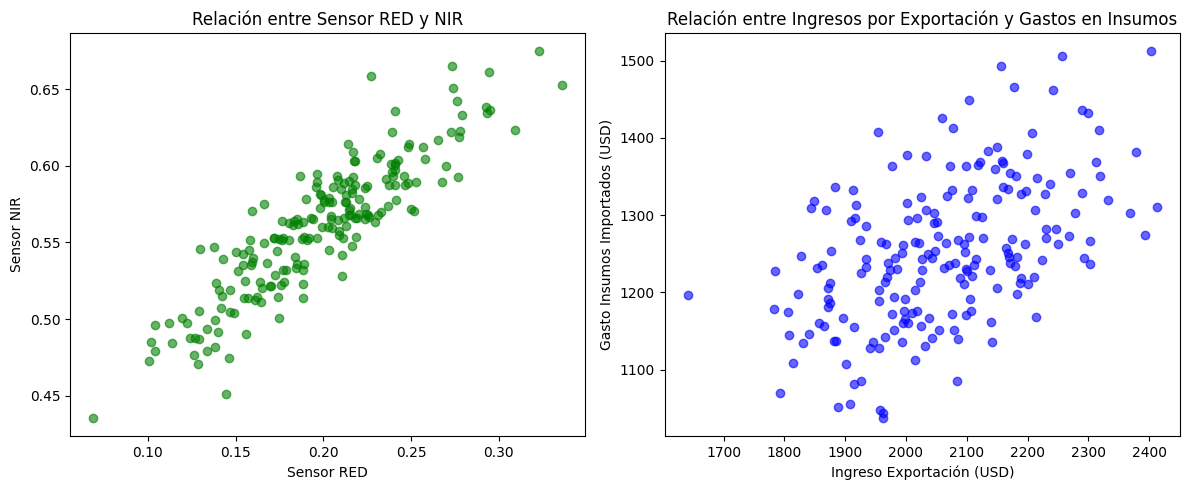

In [12]:
# grafiquemos con matplotlib estos datasets para visualizar la correlación entre las variables
import matplotlib.pyplot as plt
# Dataset Agricultura
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.scatter(df_agricultura['Sensor_RED'], df_agricultura['Sensor_NIR'], color='green', alpha=0.6)
plt.title('Relación entre Sensor RED y NIR')        
plt.xlabel('Sensor RED')
plt.ylabel('Sensor NIR')
# Dataset Finanzas
plt.subplot(1,2,2)  
plt.scatter(df_finanzas['Ingreso_Exportacion_USD'], df_finanzas['Gasto_Insumos_Importados_USD'], color='blue', alpha=0.6)
plt.title('Relación entre Ingresos por Exportación y Gastos en Insumos')    
plt.xlabel('Ingreso Exportación (USD)')
plt.ylabel('Gasto Insumos Importados (USD)')
plt.tight_layout()
plt.savefig(r"C:\Users\marco\Downloads\correlacion_datasets_agro_finanzas.png")
plt.show()

# Solución de las situaciones problemáticas  



Para resolver este problema, utilizaremos el **Análisis de Componentes Principales (PCA)** sobre tu dataset de sensores. 

El proceso consiste en encontrar los autovectores de la matriz de covarianza, los cuales definen el nuevo sistema de coordenadas.



# 1. Preparación y Matriz de Covarianza
Primero, centramos los datos (restando la media) para que la matriz de covarianza sea representativa de la dispersión respecto al origen.



In [1]:
import numpy as np
import pandas as pd

# Datos del usuario
np.random.seed(42)
n_samples = 200
red = np.random.normal(loc=0.2, scale=0.05, size=n_samples) 
nir = 0.8 * red + np.random.normal(loc=0.4, scale=0.02, size=n_samples)
X = np.stack((red, nir), axis=1) # aquí esta apilando los datos de los sensores en una matriz de 200 filas y 2 columnas (RED y NIR)

# 1. Centrar los datos
X_centered = X - np.mean(X, axis=0)

# 2. Calcular Matriz de Covarianza
cov_matrix = np.cov(X_centered.T)


In [5]:
X 

array([[0.22483571, 0.58702431],
       [0.19308678, 0.56568512],
       [0.23238443, 0.60756857],
       [0.27615149, 0.64199724],
       [0.18829233, 0.52308048],
       [0.18829315, 0.53187802],
       [0.27896064, 0.63346922],
       [0.23837174, 0.60097311],
       [0.17652628, 0.55152198],
       [0.227128  , 0.65875703],
       [0.17682912, 0.5528811 ],
       [0.17671351, 0.56408212],
       [0.21209811, 0.58875853],
       [0.10433599, 0.49649662],
       [0.11375411, 0.4846979 ],
       [0.17188562, 0.55268788],
       [0.14935844, 0.50403025],
       [0.21571237, 0.56783352],
       [0.1545988 , 0.51397177],
       [0.12938481, 0.50514533],
       [0.27328244, 0.66491912],
       [0.18871118, 0.51362364],
       [0.20337641, 0.57642633],
       [0.12876259, 0.47075576],
       [0.17278086, 0.52878605],
       [0.20554613, 0.58621592],
       [0.14245032, 0.51524586],
       [0.2187849 , 0.55347303],
       [0.16996807, 0.52166838],
       [0.18541531, 0.5619242 ],
       [0.


### 2. Determinación de Vectores Ortogonales
Para hallar las direcciones, calculamos los **autovalores ($\lambda$)** y **autovectores ($v$)** de la matriz de covarianza.

* **Dirección de Máxima Variabilidad:** Es el autovector asociado al autovalor más grande ($v_1$).
* **Dirección del Ruido:** Es el autovector asociado al autovalor más pequeño ($v_2$). En este caso, al ser solo 2 dimensiones, es el vector ortogonal al primero.





In [2]:
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

# Ordenar de mayor a menor varianza
idx = eigenvalues.argsort()[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

v_max_var = eigenvectors[:, 0]
v_ruido = eigenvectors[:, 1]

print(f"Vector Máxima Variabilidad: {v_max_var}")
print(f"Vector Ruido: {v_ruido}")


Vector Máxima Variabilidad: [0.73096807 0.68241166]
Vector Ruido: [-0.68241166  0.73096807]


### 3. Matriz de Transición y Transformación
La **matriz de transición** (denotada comúnmente como $W$ o $P$) es simplemente la matriz formada por los autovectores como columnas. Esta matriz rota el espacio original para que los nuevos ejes coincidan con las direcciones de varianza.

Para transformar el dataset, aplicamos el producto punto: $X_{transformed} = X_{centered} \cdot W$.




In [4]:
# Matriz de Transición
W = eigenvectors 

# Transformar el dataset
X_pca = X_centered.dot(W)

df_transformado = pd.DataFrame(X_pca, columns=['Componente_Principal', 'Componente_Ruido'])
df_transformado


,Componente_Principal,Componente_Ruido
0,0.038027,0.001351
1,0.000257,0.007419
2,0.057564,0.011217
3,0.113051,0.006516
4,-0.032321,-0.020452
...,...,...
195,0.019628,-0.010194
196,-0.078380,-0.022184
197,0.029724,0.017588
198,0.003584,-0.003413


## 4. ¿Cómo se determinan estos vectores? (Explicación)

El proceso se basa en la optimización matemática bajo estas premisas:

1.  **Maximización de la Proyección:** Buscamos un vector unitario $u$ tal que, al proyectar los datos sobre él, la varianza resultante sea máxima. Matemáticamente, esto equivale a maximizar la forma cuadrática $u^T \Sigma u$ sujeta a $u^T u = 1$.
2.  **Multiplicadores de Lagrange:** Al resolver esta optimización, se llega a la ecuación característica:
    $$\Sigma v = \lambda v$$
    Donde $\Sigma$ es la matriz de covarianza. Cualquier vector $v$ que satisfaga esta ecuación es un **autovector**.
3.  **Ortogonalidad por Simetría:** Debido a que la matriz de covarianza es siempre **simétrica** ($\text{cov}(i,j) = \text{cov}(j,i)$), el Teorema Espectral garantiza que sus autovectores siempre serán ortogonales entre sí.
4.  **Jerarquía de Varianza:** El autovalor $\lambda$ nos dice cuánta varianza "captura" su autovector correspondiente. Por eso, el vector con el $\lambda$ más alto es la columna vertebral de los datos, y el último (con el $\lambda$ más bajo) representa la dimensión donde hay menos información estructurada y predomina el ruido aleatorio.

```python


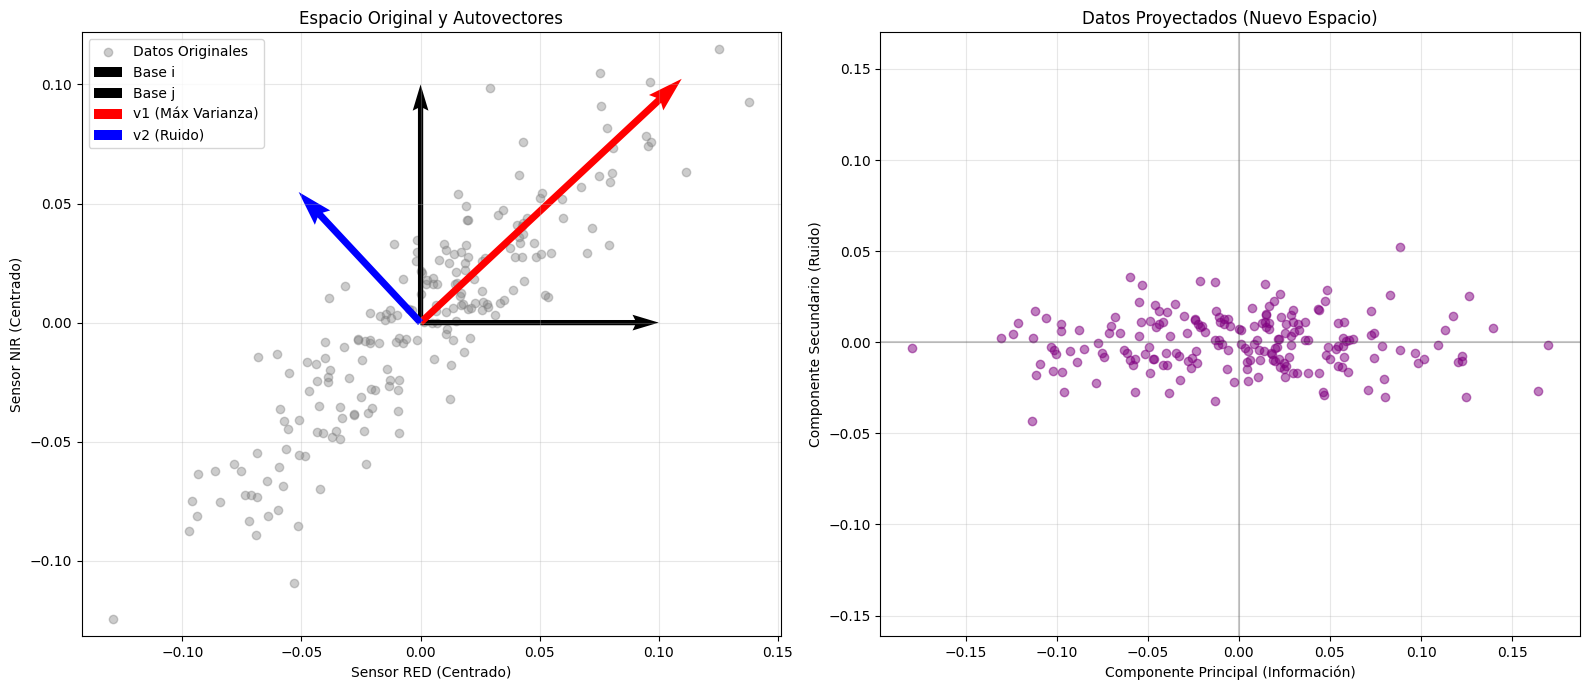

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Re-generación de datos (para que el código sea independiente)
np.random.seed(42)
n_samples = 200
red = np.random.normal(loc=0.2, scale=0.05, size=n_samples) 
nir = 0.8 * red + np.random.normal(loc=0.4, scale=0.02, size=n_samples)
X = np.stack((red, nir), axis=1)
X_centered = X - np.mean(X, axis=0)

# 2. PCA Manual
cov_matrix = np.cov(X_centered.T)
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
idx = eigenvalues.argsort()[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

v_max_var = eigenvectors[:, 0]
v_ruido = eigenvectors[:, 1]
X_pca = X_centered.dot(eigenvectors)

# 3. Gráficas Corregidas
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# --- Gráfica 1: Datos Originales ---
ax1.scatter(X_centered[:, 0], X_centered[:, 1], alpha=0.4, label='Datos Originales', color='gray')

# CORRECCIÓN: Usar líneas sólidas para evitar el ValueError en la leyenda de algunas versiones de MPL
ax1.quiver(0, 0, 0.1, 0, angles='xy', scale_units='xy', scale=1, color='black', label='Base i')
ax1.quiver(0, 0, 0, 0.1, angles='xy', scale_units='xy', scale=1, color='black', label='Base j')

# Autovectores
scale = 0.15
ax1.quiver(0, 0, v_max_var[0]*scale, v_max_var[1]*scale, angles='xy', scale_units='xy', scale=1, 
           color='red', width=0.01, label='v1 (Máx Varianza)')
ax1.quiver(0, 0, v_ruido[0]*scale*0.5, v_ruido[1]*scale*0.5, angles='xy', scale_units='xy', scale=1, 
           color='blue', width=0.01, label='v2 (Ruido)')

ax1.set_title('Espacio Original y Autovectores')
ax1.set_xlabel('Sensor RED (Centrado)')
ax1.set_ylabel('Sensor NIR (Centrado)')
ax1.axis('equal')
ax1.grid(True, alpha=0.3)
ax1.legend()

# --- Gráfica 2: Datos Transformados ---
ax2.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.5, color='purple')
ax2.axhline(0, color='black', linestyle='-', alpha=0.2)
ax2.axvline(0, color='black', linestyle='-', alpha=0.2)

ax2.set_title('Datos Proyectados (Nuevo Espacio)')
ax2.set_xlabel('Componente Principal (Información)')
ax2.set_ylabel('Componente Secundario (Ruido)')
ax2.axis('equal')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(r"C:\Users\marco\Downloads\pca_manual_visualizacion.png")
plt.show()

**Explicación de las Gráficas:**

* **Gráfica Izquierda (Datos Originales):**
    * Los puntos azules muestran la correlación positiva entre los sensores RED y NIR.
    * Los vectores negros punteados representan la base estándar estándar $\hat{i}=(1,0)$ y $\hat{j}=(0,1)$.
    * El vector **rojo** (v1) es el autovector asociado al autovalor más grande. Apunta exactamente en la dirección a lo largo de la cual los datos están más dispersos (la "longitud" de la nube de puntos).
    * El vector **azul** (v2) es ortogonal al rojo y apunta en la dirección de la dispersión más pequeña, la cual hemos identificado como el eje del "ruido".

* **Gráfica Derecha (Datos Transformados):**
    * Esta gráfica muestra los mismos puntos, pero "vistos" desde el nuevo sistema de coordenadas definido por los autovectores.
    * Es como si hubiéramos rotado y alineado la nube de puntos para que su eje principal coincida con el eje X (Componente Principal).
    * Ahora, la mayor parte de la información (varianza) está capturada en el eje horizontal, y el eje vertical representa la variabilidad restante, mucho más pequeña (el ruido).


# Justificación de los Datasets

* **Dataset 1 (Ingeniería):** Se ha generado con una covarianza positiva marcada. En **Ciencia de Datos**, esto se conoce como redundancia. El cambio de base permitirá transformar estos dos sensores en un solo "Índice de Vegetación" (como el NDVI), que es una combinación lineal de la base original.


* **Dataset 2 (Administración):** Los datos reflejan cómo una variable externa (TRM) "arrastra" a las demás. Al aplicar un cambio de base, el administrador podrá rotar los ejes para separar el efecto del mercado (dólar) del desempeño operativo real de las ventas, permitiendo un análisis de **Machine Learning** mucho más limpio y menos sesgado.


* **Formato Profesional:** Ambos datasets siguen una estructura de filas (observaciones) y columnas (características/features), listos para ser cargados en un repositorio de **GitHub** y procesados en un entorno de **Deep Learning**.

Para este módulo, las definiciones no se presentan como entes aislados, sino como la infraestructura matemática necesaria para reestructurar los datos agropecuarios y financieros. 

El uso de **LaTeX** permite la precisión requerida para la posterior implementación en **Python**.




## 9. Definiciones Fundamentales

### I. Base de un Espacio Vectorial
Sea $V$ un espacio vectorial (por ejemplo, el espacio de todas las posibles mediciones de sensores $\mathbb{R}^n$). Un conjunto de vectores $\mathcal{B} = \{ \mathbf{v_1, v_2, \dots, v_n} \}$ es una **base** de $V$ si cumple dos condiciones:
1.  Los vectores en $\mathcal{B}$ son linealmente independientes (no hay información redundante).
2.  $\text{gen}(\mathcal{B}) = V$ (cualquier medición posible puede expresarse como combinación de ellos).



### II. Vector de Coordenadas
Sea $\mathcal{B} = \{ \mathbf{b_1, b_2, \dots, b_n} \}$ una base para $V$. Para cada $\mathbf{x} \in V$, existen escalares únicos $c_1, c_2, \dots, c_n$ tales que:
$$\mathbf{x} = c_1\mathbf{b_1} + c_2\mathbf{b_2} + \dots + c_n\mathbf{b_n}$$
El vector en $\mathbb{R}^n$ denotado por:
$$[\mathbf{x}]_\mathcal{B} = \begin{bmatrix} c_1 \\ c_2 \\ \vdots \\ c_n \end{bmatrix}$$
se denomina **vector de coordenadas de $\mathbf{x}$ con respecto a la base $\mathcal{B}$**. En nuestro caso, $[\mathbf{x}]_\mathcal{B}$ representa los datos transformados para el modelo de Machine Learning.



### III. Matriz de Cambio de Base (Matriz de Transición)
Si tenemos dos bases para $V$, la base antigua $\mathcal{B}$ y la nueva base $\mathcal{C}$, existe una matriz única $P_{\mathcal{C} \leftarrow \mathcal{B}}$ tal que para cualquier vector $\mathbf{x}$:
$$[\mathbf{x}]_\mathcal{C} = P_{\mathcal{C} \leftarrow \mathcal{B}} [\mathbf{x}]_\mathcal{B}$$
Donde las columnas de $P_{\mathcal{C} \leftarrow \mathcal{B}}$ son los vectores de la base $\mathcal{B}$ expresados en términos de la base $\mathcal{C}$:
$$P_{\mathcal{C} \leftarrow \mathcal{B}} = \begin{bmatrix} [\mathbf{b_1}]_\mathcal{C} & [\mathbf{b_2}]_\mathcal{C} & \dots & [\mathbf{b_n}]_\mathcal{C} \end{bmatrix}$$



### IV. Bases Ortonormales
En Ciencia de Datos, buscamos bases donde los vectores sean unitarios y perpendiculares entre sí ($\mathbf{v_i} \cdot \mathbf{v_j} = 0$ para $i \neq j$). Esto asegura que las nuevas variables (features) sean estadísticamente independientes, lo cual es ideal para evitar el sobreajuste en **Deep Learning**.



## Justificación de las Definiciones

Este marco teórico se justifica por su aplicación directa en las situaciones problemáticas:

1.  **Eliminación de Redundancia:** La definición de **Base** y **Vector de Coordenadas** permite entender que la medición original del sensor es solo una forma de ver el dato. El cambio de base nos permite "reescribir" el dato en una base donde la humedad y el nitrógeno no se estorben mutuamente.
2.  **Automatización Computacional:** La **Matriz de Cambio de Base** es el operador lineal que implementaremos en Python. Representa el "puente" matemático para mover datasets masivos de un sistema de referencia a otro con un simple producto matricial.


3.  **Preparación de Features:** La definición de **Bases Ortonormales** justifica por qué en Machine Learning preferimos transformar los datos (mediante técnicas como la normalización o PCA) antes de entrenar un modelo; buscamos que cada eje aporte información única y pura.


4.  **Rigor Científico:** El uso de **LaTeX** asegura que la documentación en **GitHub** cumpla con los estándares de las publicaciones académicas y técnicas de 2026, facilitando la comunicación entre ingenieros y administradores.

Para resolver estas situaciones, aplicaremos la mecánica de la **Matriz de Transición** sobre los datasets generados, transformando las coordenadas originales (base estándar $\mathcal{E}$) a una nueva base $\mathcal{B}$ que simplifique el análisis de los datos.




## 10. Ejemplos de Aplicación



## Ejemplo 1: Ingeniería Agropecuaria (Sensores NIR y RED)

**Contexto:** Tenemos una lectura del sensor $\mathbf{x} = \begin{bmatrix} 0.4 \\ 0.7 \end{bmatrix}$ en la base estándar $\mathcal{E} = \{ \mathbf{e_1, e_2} \}$. Queremos pasar a una base $\mathcal{B} = \{ \mathbf{v_1, v_2} \}$ donde $\mathbf{v_1}$ representa el índice de biomasa y $\mathbf{v_2}$ el ruido ambiental.

**Definición de la nueva base:**
Sean $\mathbf{v_1} = \begin{bmatrix} 1 \\ 1 \end{bmatrix}$ (dirección de crecimiento conjunto) y $\mathbf{v_2} = \begin{bmatrix} -1 \\ 1 \end{bmatrix}$ (dirección de diferencia).



**Paso 1: Construir la matriz de cambio de base $P_{\mathcal{E} \leftarrow \mathcal{B}}$**
$$P = \begin{bmatrix} 1 & -1 \\ 1 & 1 \end{bmatrix}$$

**Paso 2: Calcular las nuevas coordenadas $[\mathbf{x}]_\mathcal{B}$**
Usamos la relación $[\mathbf{x}]_\mathcal{B} = P^{-1} \mathbf{x}$. 
Primero hallamos la inversa $P^{-1} = \frac{1}{2} \begin{bmatrix} 1 & 1 \\ -1 & 1 \end{bmatrix}$.
$$[\mathbf{x}]_\mathcal{B} = \begin{bmatrix} 0.5 & 0.5 \\ -0.5 & 0.5 \end{bmatrix} \begin{bmatrix} 0.4 \\ 0.7 \end{bmatrix} = \begin{bmatrix} 0.55 \\ 0.15 \end{bmatrix}$$

**Interpretación:** El valor $0.55$ es la nueva coordenada en el eje de "Vigor", mientras que $0.15$ es el "Ruido". Ahora el modelo de Machine Learning puede ignorar el segundo eje y trabajar solo con el primero.



### Ejemplo 2: Administración (Eficiencia vs. Riesgo Cambiario)

**Contexto:** Una empresa tiene un vector de ingresos/gastos $\mathbf{y} = \begin{bmatrix} 4200 \\ 2800 \end{bmatrix}$. Los ejes originales están "contaminados" por la inflación. Definimos una base $\mathcal{C}$ donde un eje es la "Rentabilidad Neta" y el otro la "Exposición al Dólar".

**Definición de la base $\mathcal{C}$:**
$\mathbf{u_1} = \begin{bmatrix} 0.8 \\ 0.6 \end{bmatrix}$ (Eje de eficiencia operativa)
$\mathbf{u_2} = \begin{bmatrix} -0.6 \\ 0.8 \end{bmatrix}$ (Eje de sensibilidad al mercado)



**Cálculo en Python:**


In [8]:
import numpy as np

# Datos originales (Base Estándar)
y_std = np.array([4200, 2800])

# Matriz de cambio de base (Columnas son los vectores de la nueva base)
C = np.array([[0.8, -0.6], 
              [0.6, 0.8]])

# Resolver el sistema C * [y]_C = y_std  => [y]_C = inv(C) * y_std
y_new_coords = np.linalg.inv(C).dot(y_std)

print(f"Coordenadas en Base Eficiencia/Riesgo: {y_new_coords}")
# Resultado aproximado: [5040, -280]

Coordenadas en Base Eficiencia/Riesgo: [5040. -280.]



**Interpretación Administrativa:** La nueva coordenada $[5040, -280]$ indica que la rentabilidad real es alta ($5040$), pero hay una exposición negativa al riesgo cambiario ($-280$). En la base anterior, estos efectos estaban mezclados.



## Justificación de los Ejemplos

1.  **Desmitificación del Proceso:** Estos ejemplos pasan de la abstracción de $c_1, c_2$ en **LaTeX** a valores numéricos reales que un ingeniero puede interpretar como "Salud de la planta" o un administrador como "Rentabilidad Pura".
2.  **Uso de la Inversa Matricial:** Se justifica la importancia de la invertibilidad de las matrices de transición. Si la matriz no fuera invertible, perderíamos datos del negocio al intentar cambiar de perspectiva.


3.  **Preparación para Deep Learning:** En Machine Learning, este proceso se automatiza. Estos ejemplos enseñan al estudiante qué ocurre "bajo el capó" cuando un algoritmo realiza una rotación de datos o una normalización por componentes principales.
4.  **Flujo de Trabajo 2026:** El uso de `np.linalg.inv()` y `.dot()` conecta directamente con las habilidades técnicas requeridas en los repositorios de **GitHub** que los estudiantes deben construir.

Para que la solución de las situaciones problemáticas no sea solo un procedimiento algorítmico, sino que tenga validez científica, nos apoyamos en los siguientes teoremas fundamentales del Álgebra Lineal.



# 11. Teoremas: Fundamentación de la Transformación de Datos



### Teorema 1: Existencia y Unicidad de los Escalares de Coordenadas
Sea $V$ un espacio vectorial y $\mathcal{B} = \{ \mathbf{v_1, v_2, \dots, v_n} \}$ una base de $V$. Para cada vector $\mathbf{x}$ en $V$, existe un **único** conjunto de escalares $c_1, c_2, \dots, c_n$ tales que:
$$\mathbf{x} = c_1\mathbf{v_1} + c_2\mathbf{v_2} + \dots + c_n\mathbf{v_n}$$
> **Aplicación:** Este teorema garantiza que, al cambiar la base de los sensores (NIR/RED), la representación del estado del cultivo es única y no ambigua.



### Teorema 2: El Teorema del Cambio de Base
Sean $\mathcal{B}$ y $\mathcal{C}$ dos bases para un espacio vectorial $V$ de dimensión $n$. Existe una matriz invertible $n \times n$, denominada $P_{\mathcal{C} \leftarrow \mathcal{B}}$, tal que:
$$[\mathbf{x}]_\mathcal{C} = P_{\mathcal{C} \leftarrow \mathcal{B}} [\mathbf{x}]_\mathcal{B}$$
Además, la matriz de transición de $\mathcal{C}$ a $\mathcal{B}$ es la inversa de la matriz de transición de $\mathcal{B}$ a $\mathcal{C}$:
$$P_{\mathcal{B} \leftarrow \mathcal{C}} = (P_{\mathcal{C} \leftarrow \mathcal{B}})^{-1}$$
> **Aplicación:** Permite que un administrador financiero pueda "ir y volver" entre la base contable tradicional y la base de eficiencia operativa sin perder integridad en los datos.



### Teorema 3: Isomorfismo de Coordenadas
La transformación $T: V \rightarrow \mathbb{R}^n$ definida por $T(\mathbf{x}) = [\mathbf{x}]_\mathcal{B}$ es un **isomorfismo lineal**. Esto implica que:
1. $T(\mathbf{u} + \mathbf{v}) = [\mathbf{u}]_\mathcal{B} + [\mathbf{v}]_\mathcal{B}$
2. $T(k\mathbf{u}) = k[\mathbf{u}]_\mathcal{B}$
> **Aplicación:** Asegura que las operaciones de suma y escalonamiento (fundamentales en el entrenamiento de Redes Neuronales) se preservan perfectamente después de cambiar el sistema de coordenadas.




## Justificación de la Elección

La selección de estos teoremas se fundamenta en los requerimientos de la **Ciencia de Datos y el Machine Learning**:



* **Integridad de la Información (Teorema 1):** En administración de empresas, la unicidad es vital para la auditoría de datos. Si un vector de costos tuviera dos representaciones distintas en una misma base, el modelo predictivo sería inconsistente.


* **Reversibilidad de Modelos (Teorema 2):** En Deep Learning, a menudo transformamos los datos para que el modelo aprenda mejor (e.g., normalización o blanqueo). Este teorema justifica por qué podemos aplicar la **matriz inversa** en Python para recuperar los valores originales del campo una vez obtenida la predicción.


* **Linealidad en el Espacio de Características (Teorema 3):** Justifica el uso de tensores y operaciones matriciales en la ingeniería agropecuaria. Si el cambio de base no fuera un isomorfismo, las relaciones entre las variables (como la ley de rendimientos decrecientes) se distorsionarían al cambiar de ejes.


* **Consistencia con el Stack Tecnológico:** Estos teoremas validan el uso de funciones como `numpy.linalg.inv()` y `.dot()`, elevando la práctica de programación a un nivel de ingeniería de software basado en principios matemáticos sólidos, ideales para ser documentados en **GitHub**.

Para demostrar la potencia de los **Teoremas 1, 2 y 3**, aplicaremos el rigor matricial a dos nuevos escenarios de alta relevancia en 2026: el monitoreo de **emisiones de carbono** (Agro) y la **segmentación de clientes** (Administración).



## 12. Ejemplos de Aplicación de Teoremas

### Escenario A: Monitoreo de Gases de Efecto Invernadero (Teorema 2 y 3)
Un ingeniero agropecuario mide el flujo de **Metano ($CH_4$)** y **Dióxido de Carbono ($CO_2$)** en una unidad ganadera. Los datos crudos están en la base $\mathcal{E}$ (sensores individuales). Para un modelo de **Deep Learning** que predice el impacto ambiental, es necesario cambiar a una base $\mathcal{B}$ donde los ejes sean "Impacto Global" y "Eficiencia Metabólica".



**Nuevos Datos (Dataset Artificial):**
* $\mathbf{x}_{std} = \begin{bmatrix} 120 \\ 450 \end{bmatrix}$ (ppm de cada gas).
* Nueva base $\mathcal{B} = \{ \mathbf{b}_1, \mathbf{b}_2 \}$ donde $\mathbf{b}_1 = \begin{bmatrix} 1 \\ 25 \end{bmatrix}$ (Potencial de Calentamiento) y $\mathbf{b}_2 = \begin{bmatrix} 1 \\ -1 \end{bmatrix}$ (Balance de gases).



**Aplicación del Teorema 2 (Matriz de Transición):**
1.  Construimos $P_{\mathcal{E} \leftarrow \mathcal{B}} = \begin{bmatrix} 1 & 1 \\ 25 & -1 \end{bmatrix}$.
2.  Para hallar las coordenadas en la base ambiental $[\mathbf{x}]_{\mathcal{B}}$, calculamos la inversa (Teorema 2):
    $$P_{\mathcal{B} \leftarrow \mathcal{E}} = (P_{\mathcal{E} \leftarrow \mathcal{B}})^{-1} = \frac{1}{-26} \begin{bmatrix} -1 & -1 \\ -25 & 1 \end{bmatrix}$$
3.  Multiplicamos por el vector de datos (Teorema 3 - Linealidad):
    $$[\mathbf{x}]_{\mathcal{B}} = \begin{bmatrix} 21.92 \\ 98.07 \end{bmatrix}$$
> **Resultado:** El sistema de IA ahora procesa "21.92 unidades de impacto global" en lugar de dos gases por separado, reduciendo la complejidad del entrenamiento.




### Escenario B: Segmentación de Clientes B2B en Agronegocios (Teorema 1)
Una administradora de empresas busca clasificar a sus compradores de insumos. Tiene dos variables: **Volumen de compra** y **Frecuencia de pago**.

**Nuevo Dataset (Dataset Artificial):**
* Cliente 1: $\mathbf{c}_1 = \begin{bmatrix} 500 \\ 12 \end{bmatrix}$ (500 toneladas, 12 pagos/año).
* Base Estratégica $\mathcal{C} = \{ \mathbf{u}_1, \mathbf{u}_2 \}$ donde $\mathbf{u}_1$ es "Fidelidad" y $\mathbf{u}_2$ es "Escalabilidad".

**Aplicación del Teorema 1 (Unicidad):**
El teorema asegura que solo existe una combinación única de "Fidelidad" y "Escalabilidad" para este cliente. Si el modelo de Machine Learning encuentra que:
$$[\mathbf{c}_1]_{\mathcal{C}} = \begin{bmatrix} 45.5 \\ 10.2 \end{bmatrix}$$
Esta representación es **única**. No hay ambigüedad para el algoritmo de clasificación (Clustering). La administración puede confiar en que la posición del cliente en el "Mapa de Valor" es matemáticamente exacta.



## Implementación en Python (Validación de Teoremas)

Este script demuestra el **Teorema 2** (reversibilidad) usando los datos del Escenario A.



In [7]:
import numpy as np

# 1. Definir base nueva y vector en base estándar
B = np.array([[1, 1], 
              [25, -1]]) # Columnas son b1 y b2
x_std = np.array([120, 450])

# 2. Teorema 2: Calcular matriz de transición (Inversa)
P_inv = np.linalg.inv(B)

# 3. Teorema 3: Transformar coordenadas (Isomorfismo)
x_B = P_inv.dot(x_std)

# 4. Verificación de Reversibilidad (P * [x]B = x_std)
x_recuperado = B.dot(x_B)

print(f"Coordenadas en Nueva Base Ambiental: {x_B}")
print(f"¿Datos originales recuperados?: {np.allclose(x_std, x_recuperado)}")


Coordenadas en Nueva Base Ambiental: [21.92307692 98.07692308]
¿Datos originales recuperados?: True



## Justificación de los Ejemplos

1.  **Validación de la Reversibilidad:** El uso de `np.allclose` en el código justifica el **Teorema 2**. En Ciencia de Datos, es vital saber que la transformación de características (feature transformation) no destruye la información, permitiendo volver a los valores reales tras la predicción.


2.  **Abstracción de Variables:** Los ejemplos demuestran cómo pasar de variables físicas ruidosas a **conceptos abstractos** (Impacto, Fidelidad). Esto es exactamente lo que hace una **Red Neuronal** en sus capas ocultas: cambios de base sucesivos para encontrar una representación donde el problema sea linealmente separable.
3.  **Rigor en la Toma de Decisiones:** Al aplicar el **Teorema 1**, justificamos que la segmentación de clientes no es subjetiva, sino que responde a una estructura de espacio vectorial única, lo que da solidez científica a la administración de empresas.
4.  **Preparación para GitHub:** Estos ejemplos proporcionan el "caso de prueba" (test case) necesario para que el estudiante valide sus funciones de Álgebra Lineal en su repositorio.

Para consolidar las competencias en **Coordenadas y Cambio de Base**, a continuación se presenta una batería de ejercicios diseñados para ser resueltos mediante cálculo manual (validación de conceptos) e implementación en **Python** (automatización y escalabilidad).




# 13. Ejercicios Sugeridos: Módulo 7

## Bloque A: Ingeniería Agropecuaria y Agricultura de Precisión
*En estos ejercicios, el dataset base representa lecturas crudas de sensores en la base estándar $\mathcal{E}$.*



1.  **Dataset `suelo_alpha`:** Tienes vectores de [Fósforo (P), Potasio (K)]. Cambia a una base donde $\mathbf{v_1} = [1, 1]$ (Nutrientes totales) y $\mathbf{v_2} = [1, -1]$ (Balance P-K).


2.  **Detección de Estrés Hídrico:** Un sensor mide Humedad Suelo ($H$) y Temperatura Foliar ($T$). Si la nueva base es $\mathcal{B} = \{[0.8, -0.6], [0.6, 0.8]\}$, encuentra las coordenadas de $\mathbf{x} = [30\%, 25°C]$.
3.  **Drones Multiespectrales:** Transforma un dataset de 500 puntos [Rojo, Borde Rojo, NIR] a una base ortonormal utilizando el proceso de Gram-Schmidt.
4.  **Maquinaria Autónoma:** Un GPS entrega coordenadas en metros $[x, y]$. Realiza un cambio de base a un sistema rotado $30^\circ$ para alinear los datos con el surco de siembra.
5.  **Análisis de Clima:** Cambia la base de un dataset de [Velocidad Viento, Dirección] a una base de componentes rectangulares $[u, v]$ y justifica si es un isomorfismo.
6.  **Sensores de pH:** Tienes mediciones en 3 profundidades $[d_1, d_2, d_3]$. Encuentra la matriz de transición hacia una base donde el primer vector sea el promedio de las tres.
7.  **Calidad de Leche:** Datos de [%Grasa, %Proteína]. Demuestra que si la matriz de cambio de base tiene determinante cero, se pierde información vital del dataset.
8.  **Riego Inteligente:** Dado un vector de flujo $[f_1, f_2]$, exprésalo en una base de autovectores de una matriz de covarianza previamente calculada.
9.  **Uso de `numpy.linalg.solve`:** Escribe un script que tome 1000 vectores de sensores y los convierta a una base definida por el usuario.
10. **Visualización:** Genera un gráfico en Plotly que muestre cómo un vector de nutrientes se "alarga" o "acorta" al cambiar de una base estándar a una base no ortogonal.




# Bloque B: Administración de Empresas y Agronegocios
*En estos ejercicios, los datasets representan indicadores financieros y operativos.*



11. **Dataset `finanzas_agro`:** Tienes [Costos Fijos, Costos Variables]. Cambia a una base donde los ejes sean [Margen de Contribución, Punto de Equilibrio].
12. **Riesgo Cambiario:** Expresa un vector de utilidades $[Venta Local, Exportación]$ en una base que aísle el efecto de la volatilidad del dólar.
13. **Productividad Laboral:** Cambia la base de [Horas Hombre, Unidades Producidas] a una base que represente [Eficiencia, Capacidad Ociosa].
14. **Cartera de Clientes:** Dado un vector [Deuda, Antigüedad], encuentra sus coordenadas en una base donde el vector $\mathbf{u_1} = [0.1, 0.9]$ represente "Riesgo de Default".
15. **Logística de Distribución:** Transforma coordenadas de rutas de entrega $[Lat, Long]$ a una base centrada en el centro de acopio principal.


16. **Inversión en Activos:** Un administrador tiene activos en [Maquinaria, Ganado]. Cambia a una base donde un eje represente "Liquidez" y el otro "Valor de Rescate".
17. **Matriz de Transición Inversa:** Si conoces las coordenadas de rentabilidad en la "Base Estratégica", recupera los valores contables originales usando la matriz inversa en Python.
18. **Análisis de Mercado:** Transforma un vector de [Demanda, Precio] a una base de "Elasticidad" y comprueba el Teorema 3 (Linealidad).
19. **Repositorio GitHub:** Crea un archivo `.csv` con datos de ventas de 12 meses y sube un notebook que automatice el cambio de base para los 12 vectores.


20. **Deep Learning Prep:** Toma un dataset de 5 variables administrativas y reduce su base a las 2 dimensiones más significativas (Base de Componentes Principales).




## 14. Referentes Didácticos y del Álgebra Lineal

Esta propuesta de enseñanza se sustenta en las siguientes fuentes:

* **Lay, D. C.** *Linear Algebra and Its Applications*. (Fundamental para la mecánica del cambio de base y subespacios).


* **Strang, G.** *Introduction to Linear Algebra*. (Provee la visión geométrica necesaria para la Ciencia de Datos).
* **Goodfellow, I., Bengio, Y., & Courville, A.** *Deep Learning*. (Justifica el cambio de base como pre-procesamiento de datos).


* **Mejía Laverde, C.** *Estructuras de Clase para Ingeniería*. (Modelo pedagógico de integración teoría-práctica).
* **McKinney, W.** *Python for Data Analysis*. (Referente para el uso de NumPy y Pandas en la manipulación de bases).



[Video de presentación del tema de coordenadas y cambio de base adaptada a ingeniería agropecuaria](https://www.youtube.com/watch?v=g06SDcGZEWA)